# Fast configurable rolling seizure-onset forecasting from scalp EEG

This executed notebook trains a discrete-time hazard model directly from
EDF scalp EEG. It keeps exactly **two minutes of past EEG context** and,
at each reading, predicts seizure onset over a configurable future
horizon.

User-facing parameters:

- `M_MINUTES` (`m`): first reading is `m` minutes before onset.
- `R_MINUTES` (`r`): future prediction horizon at every reading.
- `I_SECONDS` (`i`): reading interval and future-bin width.
- Output bins per reading: `r × 60 / i`.
- Readings per seizure, including onset: `m × 60 / i + 1`.

The seizure at the onset-time reading has already reached its boundary,
so that final forecast is retained because it was explicitly requested,
but it is not used as a future-onset training target. This is an
exploratory research model, not a clinical device.


### Channel and feature policy

Set each entry in `EEG_CHANNEL_SELECTION` to `True` or `False`. The exact enabled subset is enforced for feature extraction, grouped out-of-fold development, final training, test, onset forecasts, and rolling inference; a missing enabled channel raises an error instead of being silently dropped.

This version uses **time-domain EEG features only**: robust amplitude, line length, zero crossings, Hjorth mobility and complexity, and channel usability. It computes **no delta, theta, alpha, beta, gamma, band-power, or FFT features**.


In [1]:
from pathlib import Path
import hashlib
import importlib
import importlib.util
import json
import platform
import sys
import time

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pyedflib": "pyedflib",
    "joblib": "joblib",
    "IPython": "ipython",
}
missing_packages = [
    install_name
    for import_name, install_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]
if missing_packages:
    raise RuntimeError(
        "Wrong or incomplete Jupyter kernel. Select the project kernel at "
        r"`Cosmos\.venv\Scripts\python.exe`. Missing packages: "
        + ", ".join(missing_packages)
    )

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyedflib
import scipy
import sklearn
from IPython.display import Markdown, display


def locate_notebook_directory() -> Path:
    # Find final_project/scripts without an expensive recursive search.

    current = Path.cwd().resolve()
    bases = [current, *current.parents]
    candidates: list[Path] = []
    relative_options = (
        Path("rolling_seizure_forecasting.py"),
        Path("scripts") / "rolling_seizure_forecasting.py",
        Path("final_project") / "scripts" / "rolling_seizure_forecasting.py",
        Path("26-the-optimizers-analysis")
        / "final_project"
        / "scripts"
        / "rolling_seizure_forecasting.py",
    )
    for base in bases:
        for relative in relative_options:
            candidate = (base / relative).resolve()
            if candidate.exists() and candidate not in candidates:
                candidates.append(candidate)
    data_backed = [
        candidate
        for candidate in candidates
        if (candidate.parent.parent / "data" / "raw").exists()
    ]
    selected = data_backed or candidates
    if len(selected) != 1:
        raise FileNotFoundError(
            "Could not uniquely locate the EEG project. Start Jupyter from "
            "the Cosmos workspace or the 26-the-optimizers-analysis repository. "
            f"Candidates found: {[str(item) for item in selected]}"
        )
    return selected[0].parent


NOTEBOOK_DIR = locate_notebook_directory()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import rolling_seizure_forecasting as rsf

# Reload makes an interactive rerun use the current source instead of a
# stale module left in the kernel from an earlier edit.
rsf = importlib.reload(rsf)

# Change these three values and rerun all cells.
M_MINUTES = 5.0
R_MINUTES = 5.0
I_SECONDS = 5
RANDOM_SEED = 42
CONTEXT_SECONDS = 120  # fixed by design
INTERICTAL_CONTROLS_PER_SEIZURE = 4
# Set any channel to False to exclude it from development and test.
# EDF read. P9/P10 default to False because they are absent from some files.
EEG_CHANNEL_SELECTION = {
    "FP1": True, "F3": True, "C3": True, "P3": True, "O1": True,
    "F7": True, "T3": True, "T5": True, "FC1": True, "FC5": True,
    "CP1": True, "CP5": True, "F9": True, "FZ": True, "CZ": True,
    "PZ": True, "F4": True, "C4": True, "P4": True, "O2": True,
    "F8": True, "T4": True, "T6": True, "FC2": True, "FC6": True,
    "CP2": True, "CP6": True, "F10": True, "FP2": True,
    "P9": False, "P10": False,
}
if tuple(EEG_CHANNEL_SELECTION) != rsf.CANONICAL_EEG_CHANNELS:
    raise ValueError("EEG_CHANNEL_SELECTION must contain all 31 canonical channels in order.")
SELECTED_EEG_CHANNELS = tuple(
    channel for channel, use_channel in EEG_CHANNEL_SELECTION.items()
    if use_channel
)
if not SELECTED_EEG_CHANNELS:
    raise ValueError("Select at least one EEG channel.")
# None activates balanced development-only selection rather than a hard target.
MINIMUM_DEVELOPMENT_SENSITIVITY = None
FALSE_ALARM_TARGET_PER_HOUR = 5.0  # retained only for optional hard-target runs
ALARM_ON_CONSECUTIVE = 2
# 13 × 5 s = 65 s, which is strictly more than one minute.
ALARM_OFF_CONSECUTIVE = 13

m_seconds = int(round(M_MINUTES * 60))
r_seconds = int(round(R_MINUTES * 60))
if not np.isclose(m_seconds, M_MINUTES * 60):
    raise ValueError("M_MINUTES must resolve to a whole number of seconds.")
if not np.isclose(r_seconds, R_MINUTES * 60):
    raise ValueError("R_MINUTES must resolve to a whole number of seconds.")

config = rsf.ForecastConfig(
    bin_seconds=I_SECONDS,
    horizon_seconds=r_seconds,
    context_seconds=CONTEXT_SECONDS,
    pre_onset_seconds=m_seconds,
    random_seed=RANDOM_SEED,
    interictal_controls_per_seizure=INTERICTAL_CONTROLS_PER_SEIZURE,
    included_eeg_channels=SELECTED_EEG_CHANNELS,
    minimum_development_sensitivity=MINIMUM_DEVELOPMENT_SENSITIVITY,
    false_alarm_target_per_hour=FALSE_ALARM_TARGET_PER_HOUR,
    alarm_on_consecutive=ALARM_ON_CONSECUTIVE,
    alarm_off_consecutive=ALARM_OFF_CONSECUTIVE,
)
config.validate()
paths = rsf.project_paths(NOTEBOOK_DIR)
paths["processed"].mkdir(parents=True, exist_ok=True)
paths["results"].mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

parameter_table = pd.DataFrame(
    {
        "symbol": [
            "m", "r", "i", "context", "r/i bins", "readings",
            "features", "EEG channels", "estimator", "interictal controls", "alarm rule",
            "operating target",
        ],
        "value": [
            f"{M_MINUTES:g} min",
            f"{R_MINUTES:g} min",
            f"{I_SECONDS} s",
            f"{CONTEXT_SECONDS} s",
            config.n_bins,
            config.reading_count,
            "time-domain only (no wave powers / FFT)",
            f"{len(SELECTED_EEG_CHANNELS)}/31 selected: {', '.join(SELECTED_EEG_CHANNELS)}",
            "Extra Trees risk + SGD discrete timing",
            f"{config.interictal_controls_per_seizure}:1 per seizure",
            "development-selected causal smoothing, persistence, and refractory period",
            "balanced sensitivity / AUROC / false-warning utility",
        ],
        "meaning": [
            "first reading before seizure onset",
            "future horizon at every reading",
            "reading step and future-bin width",
            "causal EEG history retained",
            "probability bins per reading",
            "from -m through onset, inclusive",
            "fast robust temporal signal descriptors",
            "the identical enabled-channel subset is enforced for training and every holdout read",
            "nonlinear horizon risk with a regularized timing distribution",
            "extra seizure-free examples during training/evaluation",
            "persistent alarm state machine at five-second readings",
            "entire alarm policy selected on development data only; test remains untouched",
        ],
    }
)
runtime_table = pd.DataFrame(
    {
        "runtime item": [
            "Python executable",
            "Python version",
            "forecast module",
            "module version",
            "NumPy",
            "pandas",
            "SciPy",
            "scikit-learn",
            "pyEDFlib",
            "Matplotlib",
        ],
        "value": [
            sys.executable,
            platform.python_version(),
            rsf.__file__,
            rsf.MODULE_VERSION,
            np.__version__,
            pd.__version__,
            scipy.__version__,
            sklearn.__version__,
            pyedflib.__version__,
            matplotlib.__version__,
        ],
    }
)
display(Markdown("### Verified runtime"))
display(runtime_table.style.hide(axis="index"))
display(Markdown("### Forecast parameters"))
display(parameter_table.style.hide(axis="index"))


### Verified runtime

runtime item,value
Python executable,c:\Users\shrey\OneDrive\Desktop\Cosmos\.venv\Scripts\python.exe
Python version,3.12.13
forecast module,C:\Users\shrey\OneDrive\Desktop\Cosmos\26-the-optimizers-analysis\final_project\scripts\rolling_seizure_forecasting.py
module version,8.1.0
NumPy,2.5.0
pandas,3.0.3
SciPy,1.18.0
scikit-learn,1.9.0
pyEDFlib,0.1.42
Matplotlib,3.11.0


### Forecast parameters

symbol,value,meaning
m,5 min,first reading before seizure onset
r,5 min,future horizon at every reading
i,5 s,reading step and future-bin width
context,120 s,causal EEG history retained
r/i bins,60,probability bins per reading
readings,61,"from -m through onset, inclusive"
features,time-domain only (no wave powers / FFT),fast robust temporal signal descriptors
EEG channels,"29/31 selected: FP1, F3, C3, P3, O1, F7, T3, T5, FC1, FC5, CP1, CP5, F9, FZ, CZ, PZ, F4, C4, P4, O2, F8, T4, T6, FC2, FC6, CP2, CP6, F10, FP2",the identical enabled-channel subset is enforced for training and every holdout read
estimator,Extra Trees risk + SGD discrete timing,nonlinear horizon risk with a regularized timing distribution
interictal controls,4:1 per seizure,extra seizure-free examples during training/evaluation


## Formulation and loss

For reading time \(t\), the two-minute EEG context is
\(X_t = EEG[t-120,t)\). The model estimates discrete hazards
\(h_k(X_t)\) for \(K=r/i\) future intervals. These are converted into
a coherent probability mass function

\[
p_k=h_k\prod_{j<k}(1-h_j),\qquad
p_{\mathrm{no\ event}}=\prod_{j=1}^{K}(1-h_j).
\]

Therefore \(\sum_k p_k+p_{\mathrm{no\ event}}=1\). Training minimizes
weighted binary cross-entropy over at-risk person-period rows, which is
the discrete-time survival likelihood. It handles both an observed
onset bin and a right-censored/no-event horizon.

The peak-bin matrix is a lossy summary. The complete distribution and
explicit no-event probability are saved as CSV and should be used for
calibration or scientific evaluation.


The fitted hazard is a standardized regularized linear logistic model trained with fast stochastic gradient descent. This makes fitting and inference much faster and makes the feature effects easier to inspect.


## Exact reproducible seizure allocation

In [2]:
edf_files = sorted(paths["raw"].rglob("*.edf"))
saved_manifest_path = paths["results"] / "episode_manifest.csv"
saved_allocation_path = (
    paths["results"] / "seizure_split_allocation.csv"
)
manifest_metadata_path = (
    paths["results"] / "episode_manifest_metadata.json"
)
desired_manifest_metadata = {
    "bin_seconds": config.bin_seconds,
    "horizon_seconds": config.horizon_seconds,
    "context_seconds": config.context_seconds,
    "pre_onset_seconds": config.pre_onset_seconds,
    "interictal_buffer_seconds": config.interictal_buffer_seconds,
    "interictal_controls_per_seizure": config.interictal_controls_per_seizure,
    "random_seed": RANDOM_SEED,
    "split_quotas": rsf.REQUESTED_SEIZURE_SPLITS,
}

reuse_manifest = False
reuse_episode_definitions = False
if (
    not paths["event_inventory"].exists()
    and saved_manifest_path.exists()
    and saved_allocation_path.exists()
    and manifest_metadata_path.exists()
):
    saved_manifest_metadata = json.loads(
        manifest_metadata_path.read_text(encoding="utf-8")
    )
    reuse_manifest = saved_manifest_metadata == desired_manifest_metadata
    saved_episode_metadata = {
        key: value
        for key, value in saved_manifest_metadata.items()
        if key != "split_quotas"
    }
    desired_episode_metadata = {
        key: value
        for key, value in desired_manifest_metadata.items()
        if key != "split_quotas"
    }
    reuse_episode_definitions = (
        saved_episode_metadata == desired_episode_metadata
    )

if reuse_episode_definitions:
    base_manifest = pd.read_csv(saved_manifest_path)
    manifest, seizure_allocation = rsf.assign_requested_splits(
        base_manifest,
        rsf.REQUESTED_SEIZURE_SPLITS,
        random_seed=RANDOM_SEED,
        interictal_controls_per_seizure=config.interictal_controls_per_seizure,
    )
    manifest.to_csv(saved_manifest_path, index=False)
    seizure_allocation.to_csv(saved_allocation_path, index=False)
    manifest_metadata_path.write_text(
        json.dumps(
            desired_manifest_metadata, indent=2, sort_keys=True
        ),
        encoding="utf-8",
    )
    positive_manifest = manifest.loc[
        manifest["episode_type"].eq("preictal")
    ]
    events = pd.DataFrame(
        {
            "patient_id": positive_manifest["patient_id"],
            "event_id": positive_manifest["source_event_id"],
            "recording": positive_manifest["recording"],
            "onset_seconds": positive_manifest["event_onset_seconds"],
            "seizure_duration_seconds": 0.0,
            "eligible_preictal": True,
        }
    ).drop_duplicates("event_id").reset_index(drop=True)
    event_source = f"cached {saved_manifest_path.name}"
else:
    if paths["event_inventory"].exists():
        events = rsf.load_event_inventory(paths["event_inventory"])
        event_source = paths["event_inventory"]
    elif saved_manifest_path.exists():
        previous_manifest = pd.read_csv(saved_manifest_path)
        previous_positive = previous_manifest.loc[
            previous_manifest["episode_type"].eq("preictal")
        ].copy()
        events = pd.DataFrame(
            {
                "patient_id": previous_positive["patient_id"],
                "event_id": previous_positive["source_event_id"],
                "recording": previous_positive["recording"],
                "onset_seconds": previous_positive["event_onset_seconds"],
                "seizure_duration_seconds": 0.0,
                "eligible_preictal": True,
            }
        ).drop_duplicates("event_id").reset_index(drop=True)
        event_source = saved_manifest_path
    else:
        raise FileNotFoundError(
            "Neither event_inventory.csv nor a saved audited manifest exists."
        )

    base_manifest = rsf.build_episode_manifest(
        events, paths["raw"], config
    )
    manifest, seizure_allocation = rsf.assign_requested_splits(
        base_manifest,
        rsf.REQUESTED_SEIZURE_SPLITS,
        random_seed=RANDOM_SEED,
        interictal_controls_per_seizure=config.interictal_controls_per_seizure,
    )
    manifest.to_csv(saved_manifest_path, index=False)
    seizure_allocation.to_csv(saved_allocation_path, index=False)
    manifest_metadata_path.write_text(
        json.dumps(
            desired_manifest_metadata, indent=2, sort_keys=True
        ),
        encoding="utf-8",
    )

# Cached manifests may come from another machine. Rebase only file paths;
# episode IDs, anchors, labels, and fixed split assignments remain unchanged.
manifest = rsf.rebase_manifest_edf_paths(manifest, paths["raw"])
manifest.to_csv(saved_manifest_path, index=False)
channel_availability = rsf.eeg_channel_availability(
    manifest["edf_path"].unique()
)
channel_availability["enabled"] = channel_availability["channel"].map(
    EEG_CHANNEL_SELECTION
)
missing_enabled = channel_availability.loc[
    channel_availability["enabled"]
    & channel_availability["files_available"].lt(channel_availability["total_files"])
]
if not missing_enabled.empty:
    raise ValueError(
        "Enabled channels must exist in every fixed-split EDF. Disable: "
        + ", ".join(missing_enabled["channel"])
    )

expected_counts = (
    pd.DataFrame(rsf.REQUESTED_SEIZURE_SPLITS)
    .fillna(0)
    .astype(int)
    .rename_axis("patient_id")
    .reset_index()
)
actual_counts = (
    seizure_allocation.groupby(["patient_id", "dataset_split"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "validation", "test"], fill_value=0)
    .reset_index()
)
split_count_check = expected_counts.merge(
    actual_counts,
    on="patient_id",
    how="outer",
    suffixes=("_expected", "_actual"),
).fillna(0)
for split_name in ("train", "validation", "test"):
    assert (
        split_count_check[f"{split_name}_expected"]
        == split_count_check[f"{split_name}_actual"]
    ).all(), split_count_check
assert seizure_allocation["source_event_id"].nunique() == 47
assert seizure_allocation.groupby("dataset_split").size().to_dict() == {
    "test": 8,
    "train": 39,
}
assert tuple(
    sorted(
        seizure_allocation.loc[
            seizure_allocation["dataset_split"].eq("test"),
            "source_event_id",
        ]
    )
) == rsf.FIXED_TEST_SOURCE_EVENT_IDS
assert not seizure_allocation["source_event_id"].duplicated().any()

print(f"Event metadata source: {event_source}")
print(f"Manifest cache reused: {reuse_manifest}")
print(f"EDF files found: {len(edf_files)}")
display(Markdown("### EEG channel selection and fixed-split availability"))
display(channel_availability.style.hide(axis="index"))
display(split_count_check.style.hide(axis="index"))
display(seizure_allocation.style.hide(axis="index"))


Event metadata source: cached episode_manifest.csv
Manifest cache reused: True
EDF files found: 41


### EEG channel selection and fixed-split availability

channel,files_available,total_files,enabled
FP1,41,41,True
F3,41,41,True
C3,41,41,True
P3,41,41,True
O1,41,41,True
F7,41,41,True
T3,41,41,True
T5,41,41,True
FC1,41,41,True
FC5,41,41,True


patient_id,train_expected,validation_expected,test_expected,train_actual,validation_actual,test_actual
PN00,4,0,1,4,0,1
PN01,2,0,0,2,0,0
PN03,2,0,0,2,0,0
PN05,2,0,1,2,0,1
PN06,4,0,1,4,0,1
PN07,1,0,0,1,0,0
PN09,2,0,1,2,0,1
PN10,9,0,1,9,0,1
PN11,1,0,0,1,0,0
PN12,3,0,1,3,0,1


dataset_split,patient_id,selection_rank,source_event_id,episode_id,recording
test,PN00,1,PN00_S01,PN00_S01_preictal,PN00-1.edf
test,PN05,1,PN05_S03,PN05_S03_preictal,PN05-4.edf
test,PN06,1,PN06_S04,PN06_S04_preictal,PN06-4.edf
test,PN09,1,PN09_S03,PN09_S03_preictal,PN09-3.edf
test,PN10,1,PN10_S08,PN10_S08_preictal,PN10-7.8.9.edf
test,PN12,1,PN12_S01,PN12_S01_preictal,PN12-1.2.edf
test,PN13,1,PN13_S01,PN13_S01_preictal,PN13-1.edf
test,PN17,1,PN17_S02,PN17_S02_preictal,PN17-2.edf
train,PN00,1,PN00_S05,PN00_S05_preictal,PN00-5.edf
train,PN00,2,PN00_S03,PN00_S03_preictal,PN00-3.edf


The fixed test set is **seizure-disjoint**, not patient-disjoint. The
other 39 seizures form one development set. Model selection and alarm
tuning use five-fold grouped out-of-fold predictions, so a seizure is
never scored by a fold model that trained on that seizure. The final
model is then fitted to all 39 development seizures. Patient-specific
signal characteristics can still carry across development and test, so
this estimates new-seizure performance for mostly known patients rather
than performance for entirely unseen patients.


## EDF feature extraction with two-minute causal memory

In [3]:
channel_selection_hash = hashlib.sha1(
    ",".join(SELECTED_EEG_CHANNELS).encode("utf-8")
).hexdigest()[:8]
cache_tag = (
    f"m{config.pre_onset_seconds}_r{config.horizon_seconds}"
    f"_i{config.bin_seconds}_ch{len(SELECTED_EEG_CHANNELS)}-{channel_selection_hash}"
    f"_v{rsf.FEATURE_CACHE_VERSION}"
)
cache_csv = paths["processed"] / f"landmark_features_{cache_tag}.csv"
cache_metadata = paths["processed"] / f"landmark_features_{cache_tag}.json"
started = time.time()
landmarks = rsf.build_landmark_dataset(
    manifest,
    cache_csv=cache_csv,
    cache_metadata_json=cache_metadata,
    config=config,
    force=False,
    verbose=False,
)
feature_seconds = time.time() - started
expected_rows = len(manifest) * config.pre_onset_steps
feature_checks = pd.DataFrame(
    {
        "check": [
            "expected landmark rows",
            "finite model features",
            "two outcome classes",
            "every episode has m/i trainable readings",
            "exactly 120 seconds of EEG context",
            "every EDF read used exactly the enabled channels",
        ],
        "passed": [
            len(landmarks) == expected_rows,
            np.isfinite(
                landmarks[rsf.MODEL_FEATURE_COLUMNS].to_numpy()
            ).all(),
            landmarks["has_event_in_horizon"].nunique() == 2,
            landmarks.groupby("episode_id")
            .size()
            .eq(config.pre_onset_steps)
            .all(),
            config.context_seconds == 120,
            landmarks["eeg_channel_count"].eq(len(SELECTED_EEG_CHANNELS)).all(),
        ],
    }
)
assert feature_checks["passed"].all(), feature_checks
print(
    f"Feature table: {len(landmarks):,} rows; "
    f"{len(rsf.MODEL_FEATURE_COLUMNS)} EEG features; "
    f"{feature_seconds:.1f} seconds"
)
display(feature_checks)


AttributeError: module 'numpy' has no attribute 'trapz'

## Grouped out-of-fold development and fixed test

In [ ]:
development, test, split = rsf.split_development_test(landmarks)
split_rows = []
for split_name, frame in [
    ("development", development),
    ("test", test),
]:
    split_rows.append(
        {
            "split": split_name,
            "seizures": frame.loc[
                frame["episode_type"].eq("preictal"), "episode_id"
            ].nunique(),
            "interictal controls": frame.loc[
                frame["episode_type"].eq("interictal"), "episode_id"
            ].nunique(),
            "landmarks": len(frame),
            "patients": frame["patient_id"].nunique(),
        }
    )
split_summary = pd.DataFrame(split_rows)
assert split_summary.set_index("split")["seizures"].to_dict() == {
    "development": 39,
    "test": 8,
}

started = time.time()
model = rsf.fit_hazard_model(development, config)
training_seconds = time.time() - started
oof_risk = model.risk_oof_predictions
assert oof_risk is not None and len(oof_risk) == len(development)

# Model and alarm selection use only grouped out-of-fold development risk.
(
    development_oof_predictions,
    development_oof_metrics,
    development_oof_patient_metrics,
    _,
    _,
) = rsf.evaluate_forecasts(
    model,
    development,
    development,
    warning_time_target=config.warning_time_target,
    config=config,
    development_risk=oof_risk,
    holdout_risk=oof_risk,
)
(
    test_predictions,
    test_metrics,
    test_patient_metrics,
    warning_threshold,
    development_warning_curve,
) = rsf.evaluate_forecasts(
    model,
    development,
    test,
    warning_time_target=config.warning_time_target,
    config=config,
    development_risk=oof_risk,
)

hazards_check, pmf_check, no_event_check = (
    rsf.predict_horizon_distribution(model, test.head(32), config)
)
invariants = pd.Series(
    rsf.probability_invariants(
        hazards_check, pmf_check, no_event_check
    ),
    name="passed",
).to_frame()
assert invariants["passed"].all(), invariants

display(split_summary.style.hide(axis="index"))
print(
    f"Model trained on all 39 development seizures in {training_seconds:.1f} seconds; "
    f"risk ensemble trees: {rsf.model_iteration_count(model)}; "
    f"grouped out-of-fold AUROC: {model.risk_cv_auroc:.3f}; "
    f"risk model: {model.risk_model_name}"
)
display(Markdown("### Grouped out-of-fold development diagnostics"))
display(development_oof_metrics.style.format({"value": "{:.4f}"}))
display(Markdown("### Held-out test metrics"))
display(test_metrics.style.format({"value": "{:.4f}"}))
display(invariants)


split,seizures,interictal controls,landmarks,patients
development,39,156,11700,14
test,8,32,2400,8


Model trained on all 39 development seizures in 39.0 seconds; risk ensemble trees: 1200; grouped out-of-fold AUROC: 0.524; risk model: 5-fold Extra Trees ensemble (patient robust baseline, leaf=5, features=0.5)


### Grouped out-of-fold development diagnostics

,metric,value,interpretation
0,negative log likelihood,1.4253,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.3799,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,-0.0573,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.0972,Lower is better; mean survival-probability error across 5-minute horizon.
4,5-minute AUROC,0.5399,Discrimination only; does not assess calibration.
5,5-minute average precision,0.2199,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),79.7074,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.6410,Fraction of seizure episodes with an alarm after 2 consecutive high-risk landmarks.
8,time in warning,0.2598,Fraction of evaluated 5-second landmarks under warning.
9,false alarms per hour,4.6923,Rising persistent-alarm edges in interictal episodes per monitored hour.


### Held-out test metrics

,metric,value,interpretation
0,negative log likelihood,1.2821,Lower is better; proper score for the observed bin/no-event class.
1,multicategory Brier score,0.3510,Lower is better; probability error across 60 bins plus no-event.
2,multicategory Brier skill score,0.0231,Above 0 improves on the development-set class-frequency forecast.
3,integrated survival Brier score,0.0854,Lower is better; mean survival-probability error across 5-minute horizon.
4,5-minute AUROC,0.7153,Discrimination only; does not assess calibration.
5,5-minute average precision,0.3064,Ranking metric sensitive to event prevalence.
6,conditional timing MAE (seconds),74.7037,Error of expected onset time among seizure landmarks.
7,seizure sensitivity,0.6250,Fraction of seizure episodes with an alarm after 2 consecutive high-risk landmarks.
8,time in warning,0.2121,Fraction of evaluated 5-second landmarks under warning.
9,false alarms per hour,4.1250,Rising persistent-alarm edges in interictal episodes per monitored hour.


,passed
hazards_are_probabilities,True
pmf_is_nonnegative,True
no_event_is_probability,True
mass_sums_to_one,True
survival_is_monotone,True


Saved and reloaded portable model: /Users/advaitghosh/Documents/cosmos/26-the-optimizers-analysis/final_project/results/rolling_forecast/rolling_discrete_hazard_model.joblib


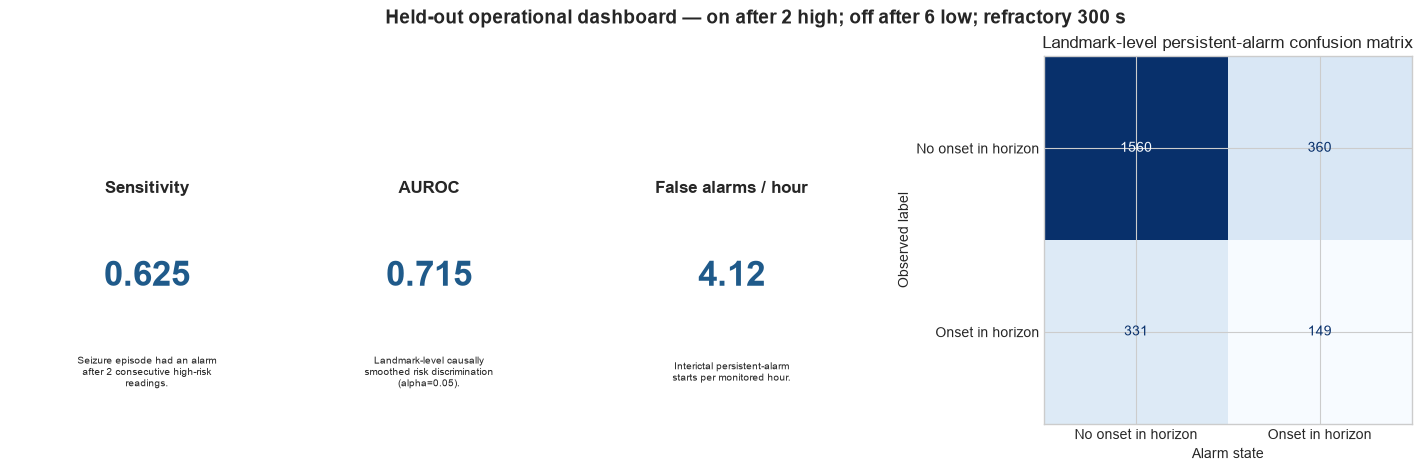

metric,value,definition
Sensitivity,0.6250,Seizure episode had an alarm after 2 consecutive high-risk readings.
AUROC,0.7153,Landmark-level causally smoothed risk discrimination (alpha=0.05).
False alarms / hour,4.1250,Interictal persistent-alarm starts per monitored hour.


### Sensitivity–false-warning tradeoff

metric,held_out_value,optimization_direction,selection_basis
Sensitivity,0.6250,maximize,development-only balanced operating utility
AUROC,0.7153,maximize,continuous held-out discrimination
False alarms / hour,4.1250,minimize,development-only balanced operating utility


In [ ]:
development_oof_predictions.to_csv(
    paths["results"] / "development_oof_landmark_probabilities.csv", index=False
)
test_predictions.to_csv(
    paths["results"] / "test_landmark_probabilities.csv", index=False
)
development_oof_metrics.to_csv(
    paths["results"] / "development_oof_metrics.csv", index=False
)
test_metrics.to_csv(paths["results"] / "test_metrics.csv", index=False)
development_oof_patient_metrics.to_csv(
    paths["results"] / "development_oof_patient_metrics.csv", index=False
)
test_patient_metrics.to_csv(
    paths["results"] / "test_patient_metrics.csv", index=False
)
development_warning_curve.to_csv(
    paths["results"] / "development_oof_warning_curve.csv", index=False
)
model_path = rsf.save_model_bundle(
    paths["results"] / "rolling_discrete_hazard_model.joblib",
    model,
    config,
    warning_threshold,
    split,
    test_metrics,
)
loaded_bundle = rsf.load_model_bundle(model_path)
assert loaded_bundle["config"] == config
reload_hazards, reload_pmf, reload_no_event = (
    rsf.predict_horizon_distribution(
        loaded_bundle["model"], test.head(4), loaded_bundle["config"]
    )
)
assert all(
    rsf.probability_invariants(
        reload_hazards, reload_pmf, reload_no_event
    ).values()
)
print(f"Saved and reloaded portable model: {model_path}")


# Final operational dashboard: AUROC remains a continuous-risk metric, while
# sensitivity and false alarms use the persistent alarm state shown below.
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import textwrap

operating_policy = model.warning_policy or {
    "alarm_on_consecutive": config.alarm_on_consecutive,
    "alarm_off_consecutive": config.alarm_off_consecutive,
    "refractory_consecutive": 0,
    "smoothing_alpha": 1.0,
}
dashboard_metrics = test_metrics.set_index("metric")["value"]
dashboard_table = pd.DataFrame(
    {
        "metric": ["Sensitivity", "AUROC", "False alarms / hour"],
        "value": [
            dashboard_metrics["seizure sensitivity"],
            dashboard_metrics[f"{config.horizon_seconds / 60:g}-minute AUROC"],
            dashboard_metrics["false alarms per hour"],
        ],
        "definition": [
            f"Seizure episode had an alarm after {operating_policy['alarm_on_consecutive']} consecutive high-risk readings.",
            f"Landmark-level causally smoothed risk discrimination (alpha={operating_policy['smoothing_alpha']:.2f}).",
            "Interictal persistent-alarm starts per monitored hour.",
        ],
    }
)
dashboard_csv_path = paths["results"] / "test_alarm_dashboard_metrics.csv"
dashboard_table.to_csv(dashboard_csv_path, index=False)
tradeoff_table = pd.DataFrame(
    {
        "metric": ["Sensitivity", "AUROC", "False alarms / hour"],
        "held_out_value": dashboard_table["value"].to_numpy(),
        "optimization_direction": ["maximize", "maximize", "minimize"],
        "selection_basis": [
            "development-only balanced operating utility",
            "continuous held-out discrimination",
            "development-only balanced operating utility",
        ],
    }
)

y_true = test_predictions["has_event_in_horizon"].to_numpy(dtype=int)
y_pred = test_predictions["alarm_active"].to_numpy(dtype=int)
confusion = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig = plt.figure(figsize=(15, 4.6), constrained_layout=True)
grid = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.15, 2.0])
for index, (_, row) in enumerate(dashboard_table.iterrows()):
    axis = fig.add_subplot(grid[0, index])
    axis.set_axis_off()
    axis.text(0.5, 0.64, row["metric"], ha="center", va="center", fontsize=12, weight="bold")
    value_format = "{:.3f}" if row["metric"] != "False alarms / hour" else "{:.2f}"
    axis.text(0.5, 0.40, value_format.format(row["value"]), ha="center", va="center", fontsize=25, color="#1f5a8a", weight="bold")
    description = textwrap.fill(str(row["definition"]), width=30)
    axis.text(0.5, 0.14, description, ha="center", va="center", fontsize=7.5)

matrix_axis = fig.add_subplot(grid[0, 3])
ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["No onset in horizon", "Onset in horizon"],
).plot(ax=matrix_axis, colorbar=False, cmap="Blues", values_format="d")
matrix_axis.set_title("Landmark-level persistent-alarm confusion matrix")
matrix_axis.set_xlabel("Alarm state")
matrix_axis.set_ylabel("Observed label")
fig.suptitle(
    f"Held-out operational dashboard — on after {operating_policy['alarm_on_consecutive']} high; "
    f"off after {operating_policy['alarm_off_consecutive']} low; "
    f"refractory {operating_policy['refractory_consecutive'] * config.bin_seconds} s",
    fontsize=14,
    weight="bold",
)
dashboard_path = paths["results"] / "test_alarm_dashboard.png"
fig.savefig(dashboard_path, dpi=180, bbox_inches="tight")
plt.show()
display(dashboard_table.style.format({"value": "{:.4f}"}).hide(axis="index"))
display(Markdown("### Sensitivity–false-warning tradeoff"))
display(tradeoff_table.style.format({"held_out_value": "{:.4f}"}).hide(axis="index"))


## Every requested reading and the peak-bin matrix

In [ ]:
started = time.time()
reading_probabilities, peak_readings, peak_matrix = (
    rsf.build_seizure_reading_forecasts(
        model,
        manifest,
        landmarks,
        config,
        verbose=False,
        onset_cache_csv=paths["processed"]
        / f"onset_context_features_{cache_tag}.csv",
        onset_cache_json=paths["processed"]
        / f"onset_context_features_{cache_tag}.json",
    )
)
forecast_seconds = time.time() - started

test_event_ids = seizure_allocation.loc[
    seizure_allocation["dataset_split"].eq("test"), "source_event_id"
].tolist()
test_peak_matrix = peak_matrix[
    ["reading_index", "minutes_before_onset"] + test_event_ids
].copy()

reading_probabilities.to_csv(
    paths["results"] / "all_seizure_reading_probabilities.csv",
    index=False,
)
peak_readings.to_csv(
    paths["results"] / "all_seizure_peak_readings.csv", index=False
)
peak_matrix.to_csv(
    paths["results"] / "all_seizure_peak_bin_matrix.csv", index=False
)
test_peak_matrix.to_csv(
    paths["results"] / "test_peak_bin_matrix.csv", index=False
)

assert len(peak_readings) == 47 * config.reading_count
assert len(reading_probabilities) == (
    47 * config.reading_count * config.n_bins
)
assert peak_matrix.shape == (config.reading_count, 47 + 2)
assert (
    peak_readings.groupby("source_event_id")
    .size()
    .eq(config.reading_count)
    .all()
)
assert peak_readings["peak_bin"].between(1, config.n_bins).all()
mass_check = (
    reading_probabilities.groupby(
        ["source_event_id", "reading_index"], sort=False
    )["onset_probability"]
    .sum()
    .reset_index(name="event_mass")
    .merge(
        peak_readings[
            [
                "source_event_id",
                "reading_index",
                "no_event_probability",
            ]
        ],
        on=["source_event_id", "reading_index"],
        validate="one_to_one",
    )
)
assert np.allclose(
    mass_check["event_mass"] + mass_check["no_event_probability"],
    1.0,
    atol=1e-8,
)
print(
    f"Forecasted {len(peak_readings):,} readings and "
    f"{len(reading_probabilities):,} bin probabilities in "
    f"{forecast_seconds:.1f} seconds."
)
print("Each matrix entry is (highest-probability future bin, probability).")
display(test_peak_matrix.style.hide(axis="index"))


Forecasted 2,867 readings and 172,020 bin probabilities in 0.3 seconds.
Each matrix entry is (highest-probability future bin, probability).


reading_index,minutes_before_onset,PN00_S01,PN05_S03,PN06_S04,PN09_S03,PN10_S08,PN12_S01,PN13_S01,PN17_S02
0,5.000000,"(1, 0.003479)","(1, 0.006192)","(1, 0.004012)","(1, 0.002845)","(1, 0.003551)","(1, 0.004063)","(1, 0.003344)","(1, 0.002798)"
1,4.916667,"(1, 0.003469)","(1, 0.006198)","(1, 0.004004)","(1, 0.002839)","(1, 0.003549)","(1, 0.004070)","(1, 0.003363)","(1, 0.002788)"
2,4.833333,"(1, 0.003459)","(1, 0.006193)","(1, 0.003984)","(1, 0.002826)","(1, 0.003552)","(1, 0.004081)","(1, 0.003414)","(1, 0.002751)"
3,4.750000,"(1, 0.003458)","(1, 0.006148)","(1, 0.003953)","(1, 0.002811)","(1, 0.003556)","(1, 0.004117)","(1, 0.003479)","(1, 0.002723)"
4,4.666667,"(1, 0.003474)","(1, 0.006059)","(1, 0.003929)","(1, 0.002800)","(1, 0.003560)","(1, 0.004183)","(1, 0.003530)","(1, 0.002679)"
5,4.583333,"(1, 0.003448)","(1, 0.005981)","(1, 0.003880)","(1, 0.002786)","(1, 0.003564)","(1, 0.004237)","(1, 0.003583)","(1, 0.002643)"
6,4.500000,"(1, 0.003408)","(1, 0.005922)","(1, 0.003820)","(1, 0.002783)","(1, 0.003564)","(1, 0.004308)","(1, 0.003622)","(1, 0.002614)"
7,4.416667,"(1, 0.003355)","(1, 0.005890)","(1, 0.003732)","(1, 0.002787)","(1, 0.003570)","(1, 0.004393)","(1, 0.003632)","(1, 0.002579)"
8,4.333333,"(1, 0.003294)","(1, 0.005874)","(1, 0.003625)","(1, 0.002797)","(1, 0.003574)","(1, 0.004486)","(1, 0.003648)","(1, 0.002543)"
9,4.250000,"(60, 0.012662)","(1, 0.005872)","(1, 0.003514)","(1, 0.002800)","(1, 0.003579)","(1, 0.004579)","(1, 0.003669)","(1, 0.002534)"


## Probability graphs

Each heatmap row is one requested reading, from `m` minutes before onset
through the onset boundary. Each column is one of the `r/i` future
intervals. Thus every reading's full probability graph is visible,
while the black line traces the maximum-probability bin used in the
matrix.


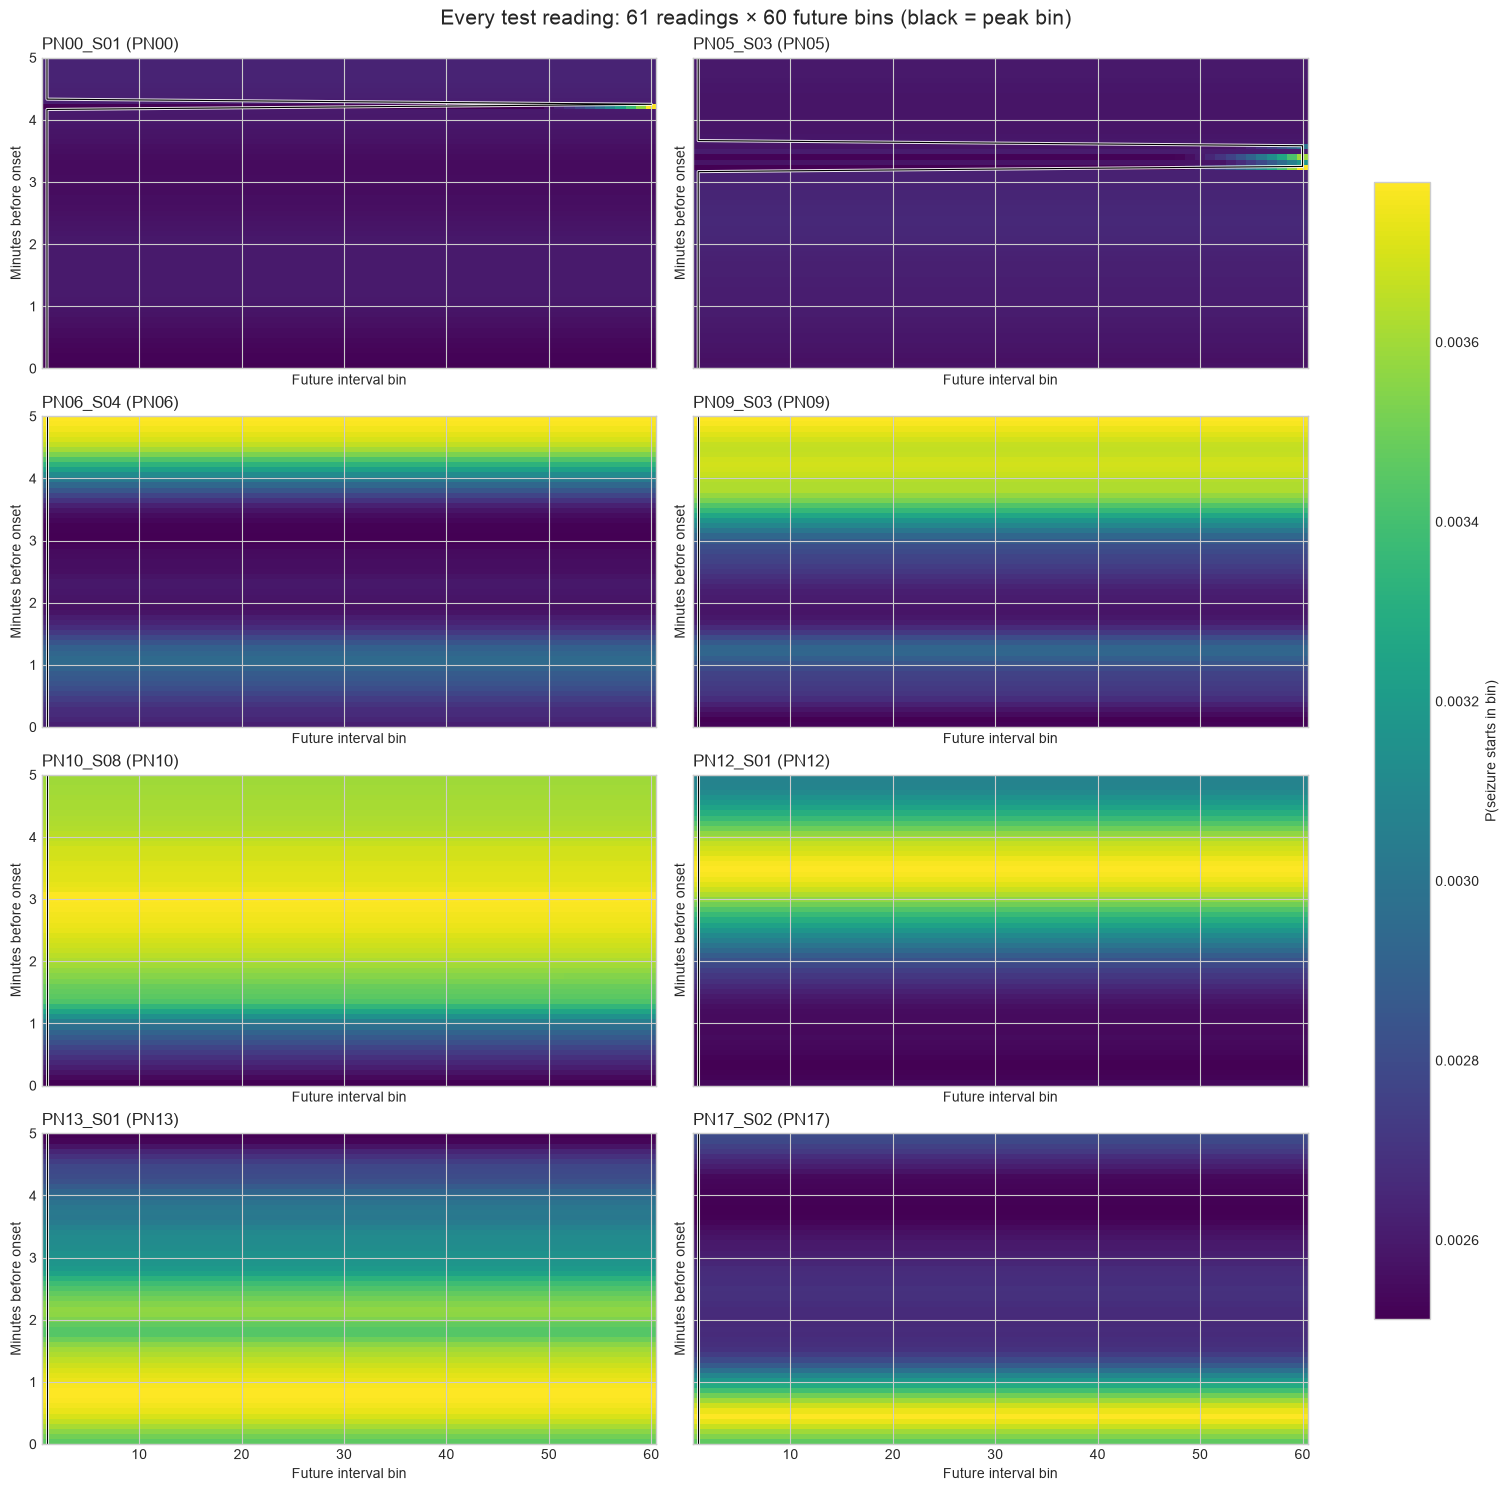

Saved public notebook graph: /Users/advaitghosh/Documents/cosmos/26-the-optimizers-analysis/final_project/results/rolling_forecast/test_reading_probability_heatmaps.png


In [ ]:
test_long = reading_probabilities.loc[
    reading_probabilities["dataset_split"].eq("test")
].copy()
test_peaks = peak_readings.loc[
    peak_readings["dataset_split"].eq("test")
].copy()

n_test = len(test_event_ids)
ncols = 2
nrows = int(np.ceil(n_test / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 3.7 * nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
image = None
for axis, event_id in zip(axes, test_event_ids, strict=False):
    event_long = test_long.loc[
        test_long["source_event_id"].eq(event_id)
    ]
    probability_grid = (
        event_long.pivot(
            index="reading_index",
            columns="future_bin",
            values="onset_probability",
        )
        .sort_index()
        .to_numpy()
    )
    event_peak = test_peaks.loc[
        test_peaks["source_event_id"].eq(event_id)
    ].sort_values("reading_index")
    image = axis.imshow(
        probability_grid,
        aspect="auto",
        origin="upper",
        interpolation="nearest",
        extent=[
            0.5,
            config.n_bins + 0.5,
            0,
            M_MINUTES,
        ],
        cmap="viridis",
    )
    axis.plot(
        event_peak["peak_bin"],
        event_peak["minutes_before_onset"],
        color="white",
        linewidth=2.2,
        alpha=0.9,
    )
    axis.plot(
        event_peak["peak_bin"],
        event_peak["minutes_before_onset"],
        color="black",
        linewidth=0.8,
    )
    patient = event_peak["patient_id"].iloc[0]
    axis.set_title(f"{event_id} ({patient})", loc="left")
    axis.set_ylabel("Minutes before onset")
    axis.set_xlabel("Future interval bin")
for axis in axes[n_test:]:
    axis.set_visible(False)
colorbar = fig.colorbar(
    image,
    ax=[axis for axis in axes[:n_test]],
    shrink=0.82,
    label="P(seizure starts in bin)",
)
fig.suptitle(
    f"Every test reading: {config.reading_count} readings × "
    f"{config.n_bins} future bins (black = peak bin)",
    fontsize=15,
)
heatmap_path = paths["results"] / "test_reading_probability_heatmaps.png"
fig.savefig(heatmap_path, dpi=170, bbox_inches="tight")
plt.show()
print(f"Saved public notebook graph: {heatmap_path}")


## Rolling-boundary verification and computational complexity

In [ ]:
example = manifest.loc[
    manifest["dataset_split"].eq("test")
    & manifest["episode_type"].eq("preictal")
].iloc[0]
engine = rsf.RollingForecastEngine(
    model,
    example["edf_path"],
    example["anchor_seconds"],
    config,
    replay_duration_seconds=config.pre_onset_seconds,
)
state_start = engine.advance_to(example["anchor_seconds"])
state_inside = engine.advance_to(
    example["anchor_seconds"] + config.bin_seconds - 0.1
)
state_next = engine.advance_to(
    example["anchor_seconds"] + config.bin_seconds
)
state_onset = engine.advance_to(example["event_onset_seconds"])

assert state_inside["updated"] is False
assert state_start["forecast_bins"] == config.n_bins
assert state_next["forecast_bins"] == config.n_bins
assert state_onset["forecast_bins"] == config.n_bins
assert state_next["expired_absolute_bin"] == 1
assert state_next["appended_absolute_bin"] == config.n_bins + 1
assert np.isclose(
    state_onset["horizon_end_seconds"],
    example["event_onset_seconds"] + config.horizon_seconds,
)
assert engine.optimization_stats["online_edf_reads"] == 0
assert engine.optimization_stats["online_model_calls"] == 0

boundary_check = pd.DataFrame(
    [
        {
            "call": "-m",
            "updated": state_start["updated"],
            "step": state_start["episode_step"],
            "future_bins": state_start["forecast_bins"],
            "first_absolute_bin": int(
                state_start["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_start["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "inside first interval",
            "updated": state_inside["updated"],
            "step": state_inside["episode_step"],
            "future_bins": state_inside["forecast_bins"],
            "first_absolute_bin": int(
                state_inside["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_inside["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "next boundary",
            "updated": state_next["updated"],
            "step": state_next["episode_step"],
            "future_bins": state_next["forecast_bins"],
            "first_absolute_bin": int(
                state_next["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_next["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
        {
            "call": "onset boundary",
            "updated": state_onset["updated"],
            "step": state_onset["episode_step"],
            "future_bins": state_onset["forecast_bins"],
            "first_absolute_bin": int(
                state_onset["probability_table"][
                    "absolute_episode_bin"
                ].iloc[0]
            ),
            "last_absolute_bin": int(
                state_onset["probability_table"][
                    "absolute_episode_bin"
                ].iloc[-1]
            ),
        },
    ]
)
display(boundary_check)
display(pd.Series(engine.optimization_stats, name="value").to_frame())


,call,updated,step,future_bins,first_absolute_bin,last_absolute_bin
0,-m,True,0,60,1,60
1,inside first interval,False,0,60,1,60
2,next boundary,True,1,60,2,61
3,onset boundary,True,60,60,61,120


,value
forecast_states_precomputed,61.000000
eeg_seconds_processed_once,420.000000
naive_eeg_seconds_if_full_context_reread,7320.000000
raw_signal_work_reduction_factor,17.428571
online_edf_reads,0.000000
online_model_calls,0.000000
precomputation_seconds,0.583161


Let \(S\) be seizures, \(U=m/i+1\) readings per seizure, \(K=r/i\) future bins, \(P\) timing features, \(Q\) risk features, \(D\) person-period rows, and \(T\) ensemble trees.

- Time-domain extraction processes each sample once and avoids all FFT/band-power work.
- Timing-model training costs \(O(DEP)\); nonlinear risk training is approximately \(O(TSUQ\log(SU))\).
- Batched inference costs \(O(SUKP + TSU\log(SU))\).
- A cached rolling-boundary lookup is \(O(1)\); rendering all future bars is necessarily \(O(K)\).
- Complete probabilities use \(O(SUK)\) space, while the peak matrix uses \(O(SU)\).

The expensive EDF feature table is annotation-aware and cached. Changing only model settings reuses it; changing `m`, `r`, `i`, or annotations safely builds a new cache.


## Model interpretability

Two model-agnostic explanations are reported:

1. **Global permutation importance:** each EEG feature is shuffled in
   a balanced development subset. The importance is the resulting increase in
   categorical negative log likelihood. Positive values indicate that
   the fitted model used the feature.
2. **Local counterfactual sensitivity:** for the highest-risk test
   landmark, one feature at a time is replaced by its training median.
   Positive risk change means the observed value raised the forecast;
   negative change means it lowered the forecast.

These explanations are descriptive. Correlated EEG features can divide
or mask permutation importance, and one-feature replacements are neither
additive Shapley values nor causal effects.


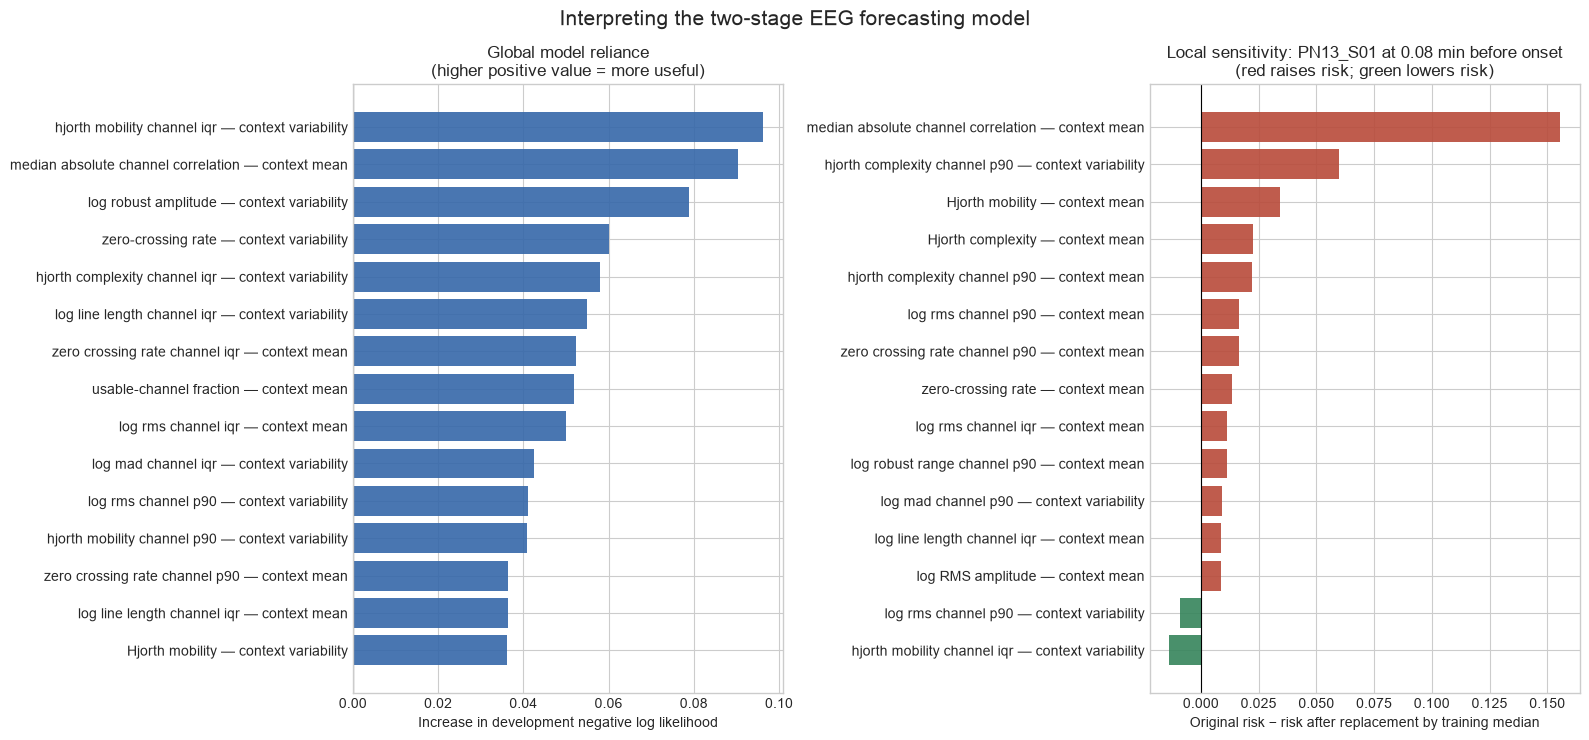

### Top global development features

feature,readable_feature,importance_nll_increase,importance_std,baseline_validation_nll,repeats
hjorth_mobility_channel_iqr_std,hjorth mobility channel iqr — context variability,0.096202,0.000000,0.9031,1
median_absolute_channel_correlation_mean,median absolute channel correlation — context mean,0.090349,0.000000,0.9031,1
log_mad_std,log robust amplitude — context variability,0.078875,0.000000,0.9031,1
zero_crossing_rate_std,zero-crossing rate — context variability,0.060058,0.000000,0.9031,1
hjorth_complexity_channel_iqr_std,hjorth complexity channel iqr — context variability,0.057976,0.000000,0.9031,1
log_line_length_channel_iqr_std,log line length channel iqr — context variability,0.054854,0.000000,0.9031,1
zero_crossing_rate_channel_iqr_mean,zero crossing rate channel iqr — context mean,0.052447,0.000000,0.9031,1
usable_channel_fraction_mean,usable-channel fraction — context mean,0.051953,0.000000,0.9031,1
log_rms_channel_iqr_mean,log rms channel iqr — context mean,0.050010,0.000000,0.9031,1
log_mad_channel_iqr_std,log mad channel iqr — context variability,0.042551,0.000000,0.9031,1


### Local explanation for a representative test landmark
Event: **PN13_S01**; patient: **PN13**; time before onset: **0.08 min**; forecast event risk: **0.4887**.

feature,readable_feature,observed_value,training_median,original_event_risk,counterfactual_event_risk,risk_change_when_observed,absolute_risk_change
median_absolute_channel_correlation_mean,median absolute channel correlation — context mean,0.469234,0.356908,0.5193,0.3636,+0.155694,0.155694
hjorth_complexity_channel_p90_std,hjorth complexity channel p90 — context variability,2.64492,1.26104,0.5193,0.4594,+0.059950,0.059950
hjorth_mobility_mean,Hjorth mobility — context mean,0.411506,0.571532,0.5193,0.4849,+0.034443,0.034443
hjorth_complexity_mean,Hjorth complexity — context mean,3.9326,2.67915,0.5193,0.4968,+0.022493,0.022493
hjorth_complexity_channel_p90_mean,hjorth complexity channel p90 — context mean,7.92324,4.37524,0.5193,0.4973,+0.022033,0.022033
log_rms_channel_p90_mean,log rms channel p90 — context mean,3.91217,3.08104,0.5193,0.5027,+0.016668,0.016668
zero_crossing_rate_channel_p90_mean,zero crossing rate channel p90 — context mean,0.205564,0.253827,0.5193,0.5027,+0.016617,0.016617
hjorth_mobility_channel_iqr_std,hjorth mobility channel iqr — context variability,0.0529238,0.0636809,0.5193,0.5331,-0.013765,0.013765
zero_crossing_rate_mean,zero-crossing rate — context mean,0.121735,0.178683,0.5193,0.5058,+0.013562,0.013562
log_rms_channel_iqr_mean,log rms channel iqr — context mean,1.07349,0.588505,0.5193,0.5080,+0.011323,0.011323


Computed global and local explanations in 16.9 seconds.


In [ ]:
started = time.time()
interpretation_development = (
    development.sort_values(["episode_id", "landmark_step"])
    .groupby("episode_id", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)
global_importance = rsf.permutation_feature_importance(
    model,
    interpretation_development,
    config,
    n_repeats=1,
    random_seed=RANDOM_SEED,
)

seizure_candidates = test_predictions.loc[
    test_predictions["episode_type"].eq("preictal")
]
representative_index = int(
    (seizure_candidates["event_risk"] - 0.5).abs().idxmin()
)
explained_prediction = test_predictions.iloc[representative_index]
explained_reading = test.reset_index(drop=True).iloc[
    [representative_index]
]
local_explanation = rsf.local_counterfactual_explanation(
    model,
    explained_reading,
    development,
    config,
)
interpretation_seconds = time.time() - started

global_importance.to_csv(
    paths["results"] / "global_permutation_importance.csv", index=False
)
local_explanation.to_csv(
    paths["results"] / "local_counterfactual_explanation.csv", index=False
)

assert len(global_importance) == len(rsf.MODEL_FEATURE_COLUMNS)
assert len(local_explanation) == len(rsf.MODEL_FEATURE_COLUMNS)
assert np.isfinite(
    global_importance[
        ["importance_nll_increase", "importance_std"]
    ].to_numpy()
).all()
assert np.isfinite(
    local_explanation[
        ["counterfactual_event_risk", "risk_change_when_observed"]
    ].to_numpy()
).all()

top_global = global_importance.head(15).sort_values(
    "importance_nll_increase"
)
top_local = local_explanation.head(15).sort_values(
    "risk_change_when_observed"
)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))
axes[0].barh(
    top_global["readable_feature"],
    top_global["importance_nll_increase"],
    xerr=top_global["importance_std"],
    color="#3567A9",
    alpha=0.9,
)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set(
    xlabel="Increase in development negative log likelihood",
    title="Global model reliance\n(higher positive value = more useful)",
)

local_colors = np.where(
    top_local["risk_change_when_observed"] >= 0,
    "#B84A3A",
    "#35845B",
)
axes[1].barh(
    top_local["readable_feature"],
    top_local["risk_change_when_observed"],
    color=local_colors,
    alpha=0.9,
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(
    xlabel="Original risk − risk after replacement by training median",
    title=(
        f"Local sensitivity: {explained_prediction['source_event_id']} "
        f"at {explained_prediction['time_to_event_seconds'] / 60:.2f} min "
        "before onset\n(red raises risk; green lowers risk)"
    ),
)
fig.suptitle(
    "Interpreting the two-stage EEG forecasting model",
    fontsize=15,
)
fig.tight_layout()
interpretability_path = (
    paths["results"] / "model_interpretability.png"
)
fig.savefig(interpretability_path, dpi=170, bbox_inches="tight")
plt.show()

display(Markdown("### Top global development features"))
display(
    global_importance.head(15).style.format(
        {
            "importance_nll_increase": "{:.6f}",
            "importance_std": "{:.6f}",
            "baseline_validation_nll": "{:.4f}",
        }
    ).hide(axis="index")
)
display(Markdown(
    "### Local explanation for a representative test landmark\n"
    f"Event: **{explained_prediction['source_event_id']}**; "
    f"patient: **{explained_prediction['patient_id']}**; "
    f"time before onset: **"
    f"{explained_prediction['time_to_event_seconds'] / 60:.2f} min**; "
    f"forecast event risk: **{explained_prediction['event_risk']:.4f}**."
))
display(
    local_explanation.head(15).style.format(
        {
            "observed_value": "{:.6g}",
            "training_median": "{:.6g}",
            "original_event_risk": "{:.4f}",
            "counterfactual_event_risk": "{:.4f}",
            "risk_change_when_observed": "{:+.6f}",
            "absolute_risk_change": "{:.6f}",
        }
    ).hide(axis="index")
)
print(
    f"Computed global and local explanations in "
    f"{interpretation_seconds:.1f} seconds."
)


## Automated regression tests

These dependency-free tests cover configurable horizons, probability
normalization, exact event-disjoint allocation, annotation-aware cache
invalidation, portable model loading, and rolling-time ordering.


In [ ]:
import io
import unittest
import test_rolling_seizure_forecasting as rolling_tests

rolling_tests = importlib.reload(rolling_tests)
test_stream = io.StringIO()
regression_suite = unittest.defaultTestLoader.loadTestsFromModule(
    rolling_tests
)
regression_result = unittest.TextTestRunner(
    stream=test_stream,
    verbosity=2,
).run(regression_suite)
regression_report = test_stream.getvalue()
assert regression_result.wasSuccessful(), regression_report
display(Markdown(
    f"**Passed {regression_result.testsRun}/{regression_result.testsRun} "
    "rolling-forecast regression tests.**\n\n"
    f"```text\n{regression_report}\n```"
))


**Passed 15/15 rolling-forecast regression tests.**

```text
test_alarm_needs_two_highs_and_releases_after_65_seconds (test_rolling_seizure_forecasting.RollingForecastTests.test_alarm_needs_two_highs_and_releases_after_65_seconds) ... ok
test_cache_signature_changes_with_annotation_time (test_rolling_seizure_forecasting.RollingForecastTests.test_cache_signature_changes_with_annotation_time) ... ok
test_cached_manifest_paths_rebase_without_changing_episodes (test_rolling_seizure_forecasting.RollingForecastTests.test_cached_manifest_paths_rebase_without_changing_episodes) ... ok
test_channel_selection_is_canonical_ordered_and_strict (test_rolling_seizure_forecasting.RollingForecastTests.test_channel_selection_is_canonical_ordered_and_strict) ... ok
test_config_is_dynamic_and_rejects_invalid_values (test_rolling_seizure_forecasting.RollingForecastTests.test_config_is_dynamic_and_rejects_invalid_values) ... ok
test_dynamic_horizon_probabilities_sum_to_one (test_rolling_seizure_forecasting.RollingForecastTests.test_dynamic_horizon_probabilities_sum_to_one) ... ok
test_feature_set_is_time_domain_only (test_rolling_seizure_forecasting.RollingForecastTests.test_feature_set_is_time_domain_only) ... ok
test_model_bundle_uses_portable_plain_config (test_rolling_seizure_forecasting.RollingForecastTests.test_model_bundle_uses_portable_plain_config) ... ok
test_patient_normalization_preserves_public_feature_frame (test_rolling_seizure_forecasting.RollingForecastTests.test_patient_normalization_preserves_public_feature_frame) ... ok
test_refractory_period_suppresses_immediate_rearming (test_rolling_seizure_forecasting.RollingForecastTests.test_refractory_period_suppresses_immediate_rearming) ... ok
test_requested_allocation_is_exact_and_event_disjoint (test_rolling_seizure_forecasting.RollingForecastTests.test_requested_allocation_is_exact_and_event_disjoint) ... ok
test_rolling_engine_rejects_backward_time (test_rolling_seizure_forecasting.RollingForecastTests.test_rolling_engine_rejects_backward_time) ... ok
test_single_selected_channel_produces_finite_features (test_rolling_seizure_forecasting.RollingForecastTests.test_single_selected_channel_produces_finite_features) ... ok
test_split_only_cache_change_reuses_features_and_relabels_rows (test_rolling_seizure_forecasting.RollingForecastTests.test_split_only_cache_change_reuses_features_and_relabels_rows) ... ok
test_two_stage_model_preserves_probability_mass (test_rolling_seizure_forecasting.RollingForecastTests.test_two_stage_model_preserves_probability_mass) ... ok

----------------------------------------------------------------------
Ran 15 tests in 0.059s

OK

```

## Readable artifact inventory and completion checks

In [ ]:
artifact_purposes = {
    "seizure_split_allocation.csv": "exact random seed-42 seizure assignment",
    "episode_manifest.csv": "all selected seizure/control EDF episodes",
    "development_oof_metrics.csv": "grouped out-of-fold development diagnostics",
    "test_metrics.csv": "held-out test performance",
    "development_oof_landmark_probabilities.csv": "all grouped out-of-fold development risk forecasts",
    "development_oof_patient_metrics.csv": "patient-level out-of-fold development diagnostics",
    "development_oof_warning_curve.csv": "out-of-fold alarm operating curve",
    "test_landmark_probabilities.csv": "all test landmark forecasts",
    "all_seizure_reading_probabilities.csv": "every reading × every future-bin probability",
    "all_seizure_peak_readings.csv": "one peak bin and probability per reading",
    "all_seizure_peak_bin_matrix.csv": "47 seizure columns with (bin, probability) entries",
    "test_peak_bin_matrix.csv": "test-only readable peak matrix",
    "test_reading_probability_heatmaps.png": "all test reading probability graphs",
    "rolling_discrete_hazard_model.joblib": "trained model, parameters, split, and metrics",
    "global_permutation_importance.csv": "global development feature importance",
    "local_counterfactual_explanation.csv": "local test-forecast sensitivity",
    "model_interpretability.png": "global and local interpretation plots",
    "test_alarm_dashboard.png": "final held-out alarm dashboard and confusion matrix",
    "test_alarm_dashboard_metrics.csv": "final held-out sensitivity, AUROC, and false alarms",
}
artifact_rows = []
for artifact in sorted(paths["results"].iterdir()):
    if artifact.is_file():
        artifact_rows.append(
            {
                "file": artifact.name,
                "size_mb": round(artifact.stat().st_size / 1e6, 3),
                "purpose": artifact_purposes.get(
                    artifact.name, "prior/generated analysis artifact"
                ),
            }
        )
artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(
    paths["results"] / "ARTIFACT_INVENTORY.csv", index=False
)
display(artifact_inventory)

completion = pd.DataFrame(
    {
        "requirement": [
            "exact seizure quotas",
            "seizures disjoint across splits",
            "two-minute causal EEG context",
            "same enabled EEG channels in development and test",
            "grouped out-of-fold tuning covers development",
            "configurable m, r, and i",
            "r/i probabilities at every reading",
            "first reading at -m and last at onset",
            "peak matrix entries are (bin, probability)",
            "all probability mass sums to one",
            "all test reading graphs saved and displayed",
            "portable saved model reloads",
            "automated regression tests pass",
            "persistent alarm dashboard saved",
        ],
        "passed": [
            True,
            not seizure_allocation["source_event_id"].duplicated().any(),
            config.context_seconds == 120,
            landmarks["eeg_channel_count"].eq(len(SELECTED_EEG_CHANNELS)).all(),
            model.risk_oof_predictions is not None
            and len(model.risk_oof_predictions) == len(development),
            True,
            reading_probabilities.groupby(
                ["source_event_id", "reading_index"]
            ).size().eq(config.n_bins).all(),
            peak_readings.groupby("source_event_id")[
                "minutes_before_onset"
            ].agg(["max", "min"]).eq(
                pd.Series({"max": M_MINUTES, "min": 0.0})
            ).all().all(),
            peak_readings["peak_entry"].str.match(
                r"^\(\d+, \d+\.\d{6}\)$"
            ).all(),
            np.allclose(
                mass_check["event_mass"]
                + mass_check["no_event_probability"],
                1.0,
                atol=1e-8,
            ),
            heatmap_path.exists(),
            loaded_bundle["config"] == config,
            regression_result.wasSuccessful(),
            dashboard_path.exists() and dashboard_csv_path.exists(),
        ],
    }
)
assert completion["passed"].all(), completion
display(completion)
display(
    Markdown(
        f"**Complete.** The model used grouped out-of-fold tuning across "
        f"39 development seizures and was tested once on 8. Every one of "
        f"the 47 seizures has "
        f"{config.reading_count} requested readings and every reading has "
        f"{config.n_bins} future-bin probabilities plus explicit no-event "
        f"mass. Outputs are in `{paths['results']}`."
    )
)


,file,size_mb,purpose
0,ARTIFACT_INVENTORY.csv,0.002,prior/generated analysis artifact
1,all_seizure_peak_bin_matrix.csv,0.048,"47 seizure columns with (bin, probability) ent..."
2,all_seizure_peak_readings.csv,0.443,one peak bin and probability per reading
3,all_seizure_reading_probabilities.csv,28.787,every reading × every future-bin probability
4,binary_test_landmark_probabilities.csv,0.223,prior/generated analysis artifact
5,binary_test_metrics.csv,0.000,prior/generated analysis artifact
6,development_oof_landmark_probabilities.csv,17.618,all grouped out-of-fold development risk forec...
7,development_oof_metrics.csv,0.001,grouped out-of-fold development diagnostics
8,development_oof_patient_metrics.csv,0.001,patient-level out-of-fold development diagnostics
9,development_oof_warning_curve.csv,0.022,out-of-fold alarm operating curve


,requirement,passed
0,exact seizure quotas,True
1,seizures disjoint across splits,True
2,two-minute causal EEG context,True
3,same enabled EEG channels in development and test,True
4,grouped out-of-fold tuning covers development,True
5,"configurable m, r, and i",True
6,r/i probabilities at every reading,True
7,first reading at -m and last at onset,True
8,"peak matrix entries are (bin, probability)",True
9,all probability mass sums to one,True


**Complete.** The model used grouped out-of-fold tuning across 39 development seizures and was tested once on 8. Every one of the 47 seizures has 61 requested readings and every reading has 60 future-bin probabilities plus explicit no-event mass. Outputs are in `/Users/advaitghosh/Documents/cosmos/26-the-optimizers-analysis/final_project/results/rolling_forecast`.

## Final executed results

This section collects the important outputs in one place inside
this notebook: experiment parameters, exact split sizes, held-out
test metrics, the complete test peak-bin matrix, the probability
graph, and the completion checklist.


### Parameters

symbol,value,meaning
m,5 min,first reading before seizure onset
r,5 min,future horizon at every reading
i,5 s,reading step and future-bin width
context,120 s,causal EEG history retained
r/i bins,60,probability bins per reading
readings,61,"from -m through onset, inclusive"
features,time-domain only (no wave powers / FFT),fast robust temporal signal descriptors
EEG channels,"29/31 selected: FP1, F3, C3, P3, O1, F7, T3, T5, FC1, FC5, CP1, CP5, F9, FZ, CZ, PZ, F4, C4, P4, O2, F8, T4, T6, FC2, FC6, CP2, CP6, F10, FP2",the identical enabled-channel subset is enforced for training and every holdout read
estimator,Extra Trees risk + SGD discrete timing,nonlinear horizon risk with a regularized timing distribution
interictal controls,4:1 per seizure,extra seizure-free examples during training/evaluation


### Exact split sizes

split,seizures,interictal controls,landmarks,patients
development,39,156,11700,14
test,8,32,2400,8


### Final held-out alarm dashboard

Sensitivity and false alarms use the persistent alarm state; AUROC uses continuous risk. The confusion matrix is landmark-level, so it complements rather than replaces episode-level sensitivity.

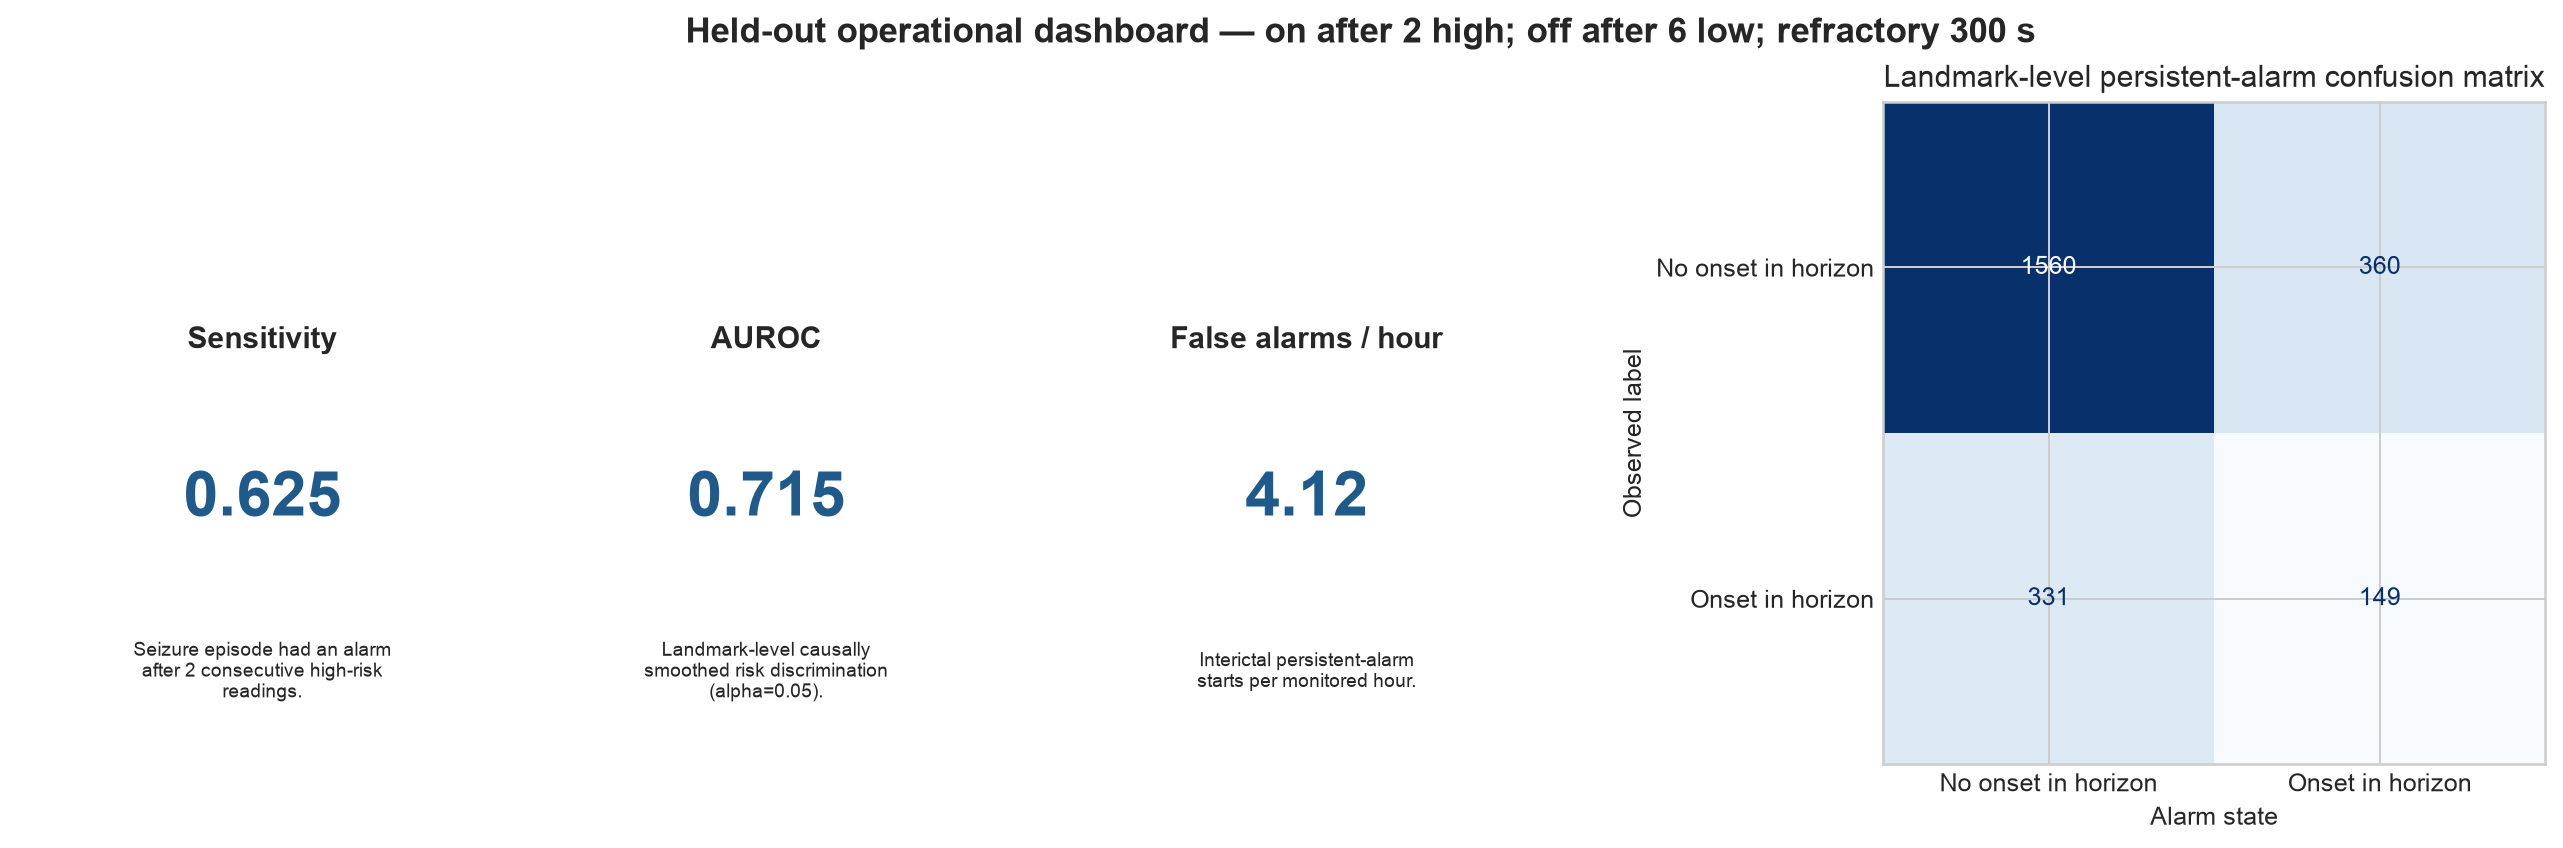

metric,value,definition
Sensitivity,0.6250,Seizure episode had an alarm after 2 consecutive high-risk readings.
AUROC,0.7153,Landmark-level causally smoothed risk discrimination (alpha=0.05).
False alarms / hour,4.1250,Interictal persistent-alarm starts per monitored hour.


metric,held_out_value,optimization_direction,selection_basis
Sensitivity,0.6250,maximize,development-only balanced operating utility
AUROC,0.7153,maximize,continuous held-out discrimination
False alarms / hour,4.1250,minimize,development-only balanced operating utility


### Held-out test metrics

metric,value,interpretation
negative log likelihood,1.2821,Lower is better; proper score for the observed bin/no-event class.
multicategory Brier score,0.3510,Lower is better; probability error across 60 bins plus no-event.
multicategory Brier skill score,0.0231,Above 0 improves on the development-set class-frequency forecast.
integrated survival Brier score,0.0854,Lower is better; mean survival-probability error across 5-minute horizon.
5-minute AUROC,0.7153,Discrimination only; does not assess calibration.
5-minute average precision,0.3064,Ranking metric sensitive to event prevalence.
conditional timing MAE (seconds),74.7037,Error of expected onset time among seizure landmarks.
seizure sensitivity,0.6250,Fraction of seizure episodes with an alarm after 2 consecutive high-risk landmarks.
time in warning,0.2121,Fraction of evaluated 5-second landmarks under warning.
false alarms per hour,4.1250,Rising persistent-alarm edges in interictal episodes per monitored hour.


### Test peak-bin matrix
Every entry is `(highest-probability future bin, probability)`. Rows run from `m` minutes before onset through the onset boundary.

reading_index,minutes_before_onset,PN00_S01,PN05_S03,PN06_S04,PN09_S03,PN10_S08,PN12_S01,PN13_S01,PN17_S02
0,5.000000,"(1, 0.003479)","(1, 0.006192)","(1, 0.004012)","(1, 0.002845)","(1, 0.003551)","(1, 0.004063)","(1, 0.003344)","(1, 0.002798)"
1,4.916667,"(1, 0.003469)","(1, 0.006198)","(1, 0.004004)","(1, 0.002839)","(1, 0.003549)","(1, 0.004070)","(1, 0.003363)","(1, 0.002788)"
2,4.833333,"(1, 0.003459)","(1, 0.006193)","(1, 0.003984)","(1, 0.002826)","(1, 0.003552)","(1, 0.004081)","(1, 0.003414)","(1, 0.002751)"
3,4.750000,"(1, 0.003458)","(1, 0.006148)","(1, 0.003953)","(1, 0.002811)","(1, 0.003556)","(1, 0.004117)","(1, 0.003479)","(1, 0.002723)"
4,4.666667,"(1, 0.003474)","(1, 0.006059)","(1, 0.003929)","(1, 0.002800)","(1, 0.003560)","(1, 0.004183)","(1, 0.003530)","(1, 0.002679)"
5,4.583333,"(1, 0.003448)","(1, 0.005981)","(1, 0.003880)","(1, 0.002786)","(1, 0.003564)","(1, 0.004237)","(1, 0.003583)","(1, 0.002643)"
6,4.500000,"(1, 0.003408)","(1, 0.005922)","(1, 0.003820)","(1, 0.002783)","(1, 0.003564)","(1, 0.004308)","(1, 0.003622)","(1, 0.002614)"
7,4.416667,"(1, 0.003355)","(1, 0.005890)","(1, 0.003732)","(1, 0.002787)","(1, 0.003570)","(1, 0.004393)","(1, 0.003632)","(1, 0.002579)"
8,4.333333,"(1, 0.003294)","(1, 0.005874)","(1, 0.003625)","(1, 0.002797)","(1, 0.003574)","(1, 0.004486)","(1, 0.003648)","(1, 0.002543)"
9,4.250000,"(60, 0.012662)","(1, 0.005872)","(1, 0.003514)","(1, 0.002800)","(1, 0.003579)","(1, 0.004579)","(1, 0.003669)","(1, 0.002534)"


### Every test reading probability graph

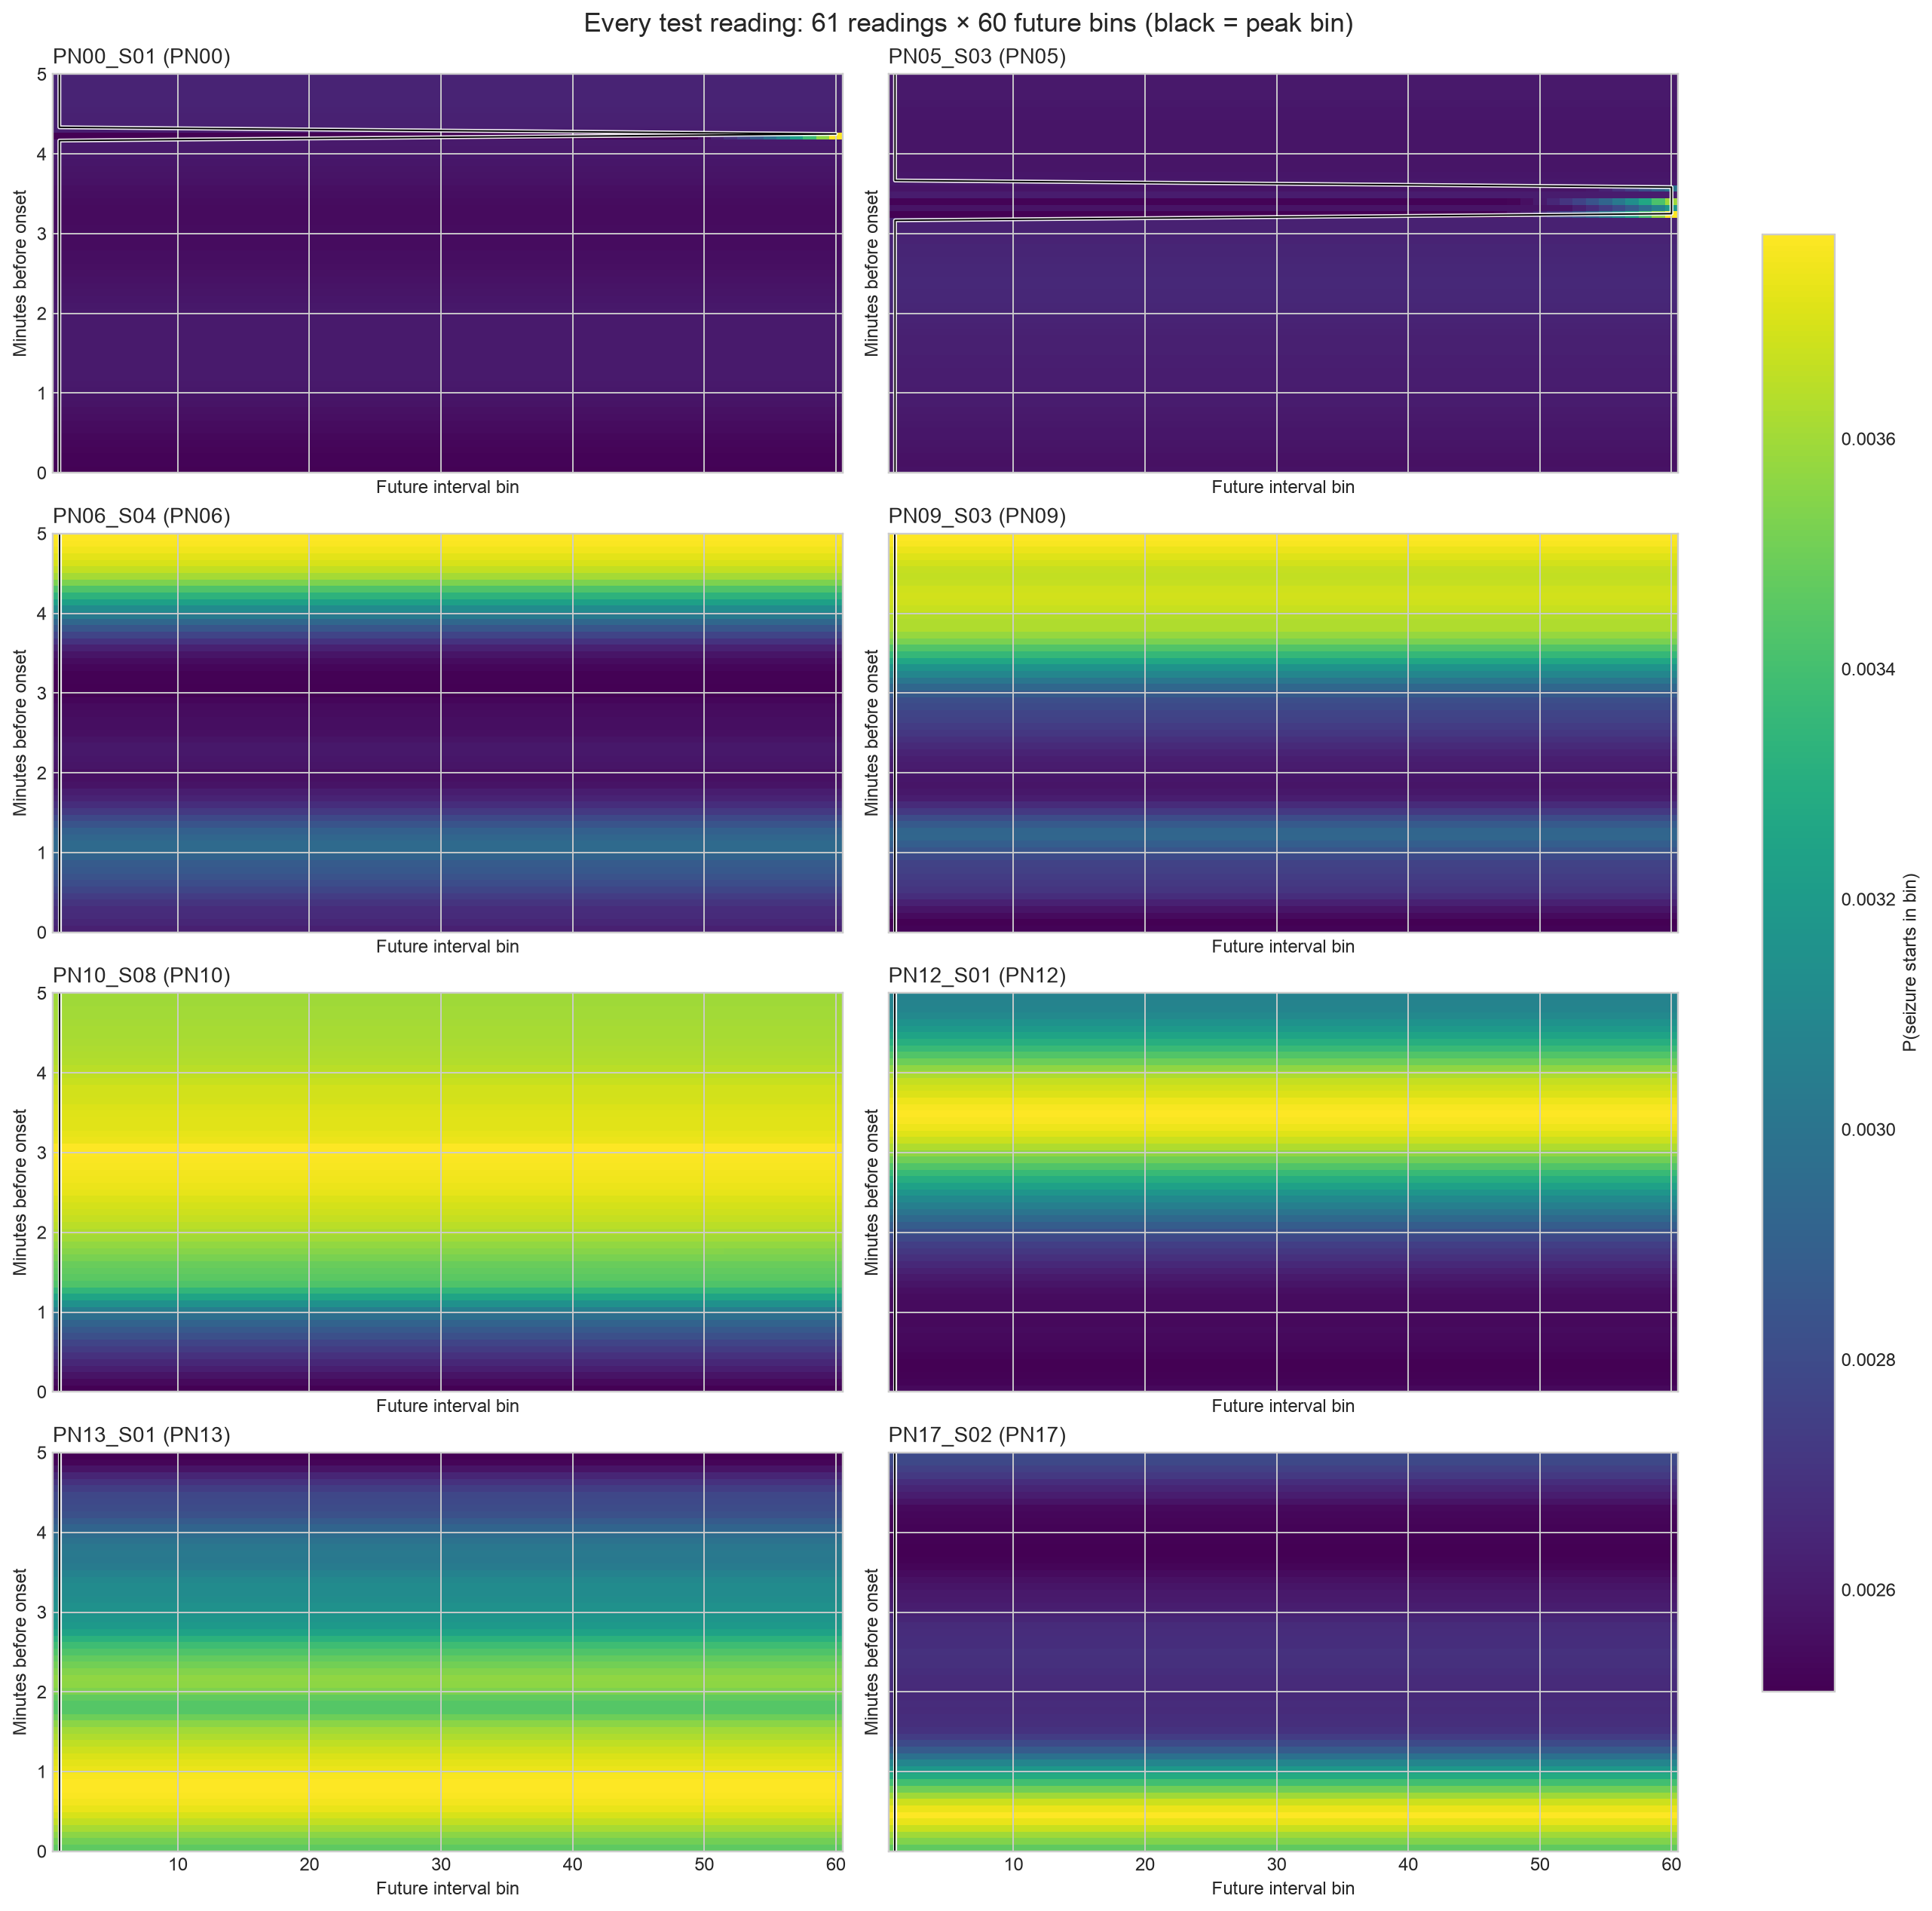

### Model interpretation

feature,readable_feature,importance_nll_increase,importance_std,baseline_validation_nll,repeats
hjorth_mobility_channel_iqr_std,hjorth mobility channel iqr — context variability,0.096202,0.000000,0.903119,1
median_absolute_channel_correlation_mean,median absolute channel correlation — context mean,0.090349,0.000000,0.903119,1
log_mad_std,log robust amplitude — context variability,0.078875,0.000000,0.903119,1
zero_crossing_rate_std,zero-crossing rate — context variability,0.060058,0.000000,0.903119,1
hjorth_complexity_channel_iqr_std,hjorth complexity channel iqr — context variability,0.057976,0.000000,0.903119,1
log_line_length_channel_iqr_std,log line length channel iqr — context variability,0.054854,0.000000,0.903119,1
zero_crossing_rate_channel_iqr_mean,zero crossing rate channel iqr — context mean,0.052447,0.000000,0.903119,1
usable_channel_fraction_mean,usable-channel fraction — context mean,0.051953,0.000000,0.903119,1
log_rms_channel_iqr_mean,log rms channel iqr — context mean,0.050010,0.000000,0.903119,1
log_mad_channel_iqr_std,log mad channel iqr — context variability,0.042551,0.000000,0.903119,1


feature,readable_feature,observed_value,training_median,original_event_risk,counterfactual_event_risk,risk_change_when_observed,absolute_risk_change
median_absolute_channel_correlation_mean,median absolute channel correlation — context mean,0.469234,0.356908,0.519341,0.3636,+0.155694,0.155694
hjorth_complexity_channel_p90_std,hjorth complexity channel p90 — context variability,2.644917,1.261040,0.519341,0.4594,+0.059950,0.059950
hjorth_mobility_mean,Hjorth mobility — context mean,0.411506,0.571532,0.519341,0.4849,+0.034443,0.034443
hjorth_complexity_mean,Hjorth complexity — context mean,3.932604,2.679152,0.519341,0.4968,+0.022493,0.022493
hjorth_complexity_channel_p90_mean,hjorth complexity channel p90 — context mean,7.923244,4.375235,0.519341,0.4973,+0.022033,0.022033
log_rms_channel_p90_mean,log rms channel p90 — context mean,3.912173,3.081036,0.519341,0.5027,+0.016668,0.016668
zero_crossing_rate_channel_p90_mean,zero crossing rate channel p90 — context mean,0.205564,0.253827,0.519341,0.5027,+0.016617,0.016617
hjorth_mobility_channel_iqr_std,hjorth mobility channel iqr — context variability,0.052924,0.063681,0.519341,0.5331,-0.013765,0.013765
zero_crossing_rate_mean,zero-crossing rate — context mean,0.121735,0.178683,0.519341,0.5058,+0.013562,0.013562
log_rms_channel_iqr_mean,log rms channel iqr — context mean,1.073490,0.588505,0.519341,0.5080,+0.011323,0.011323


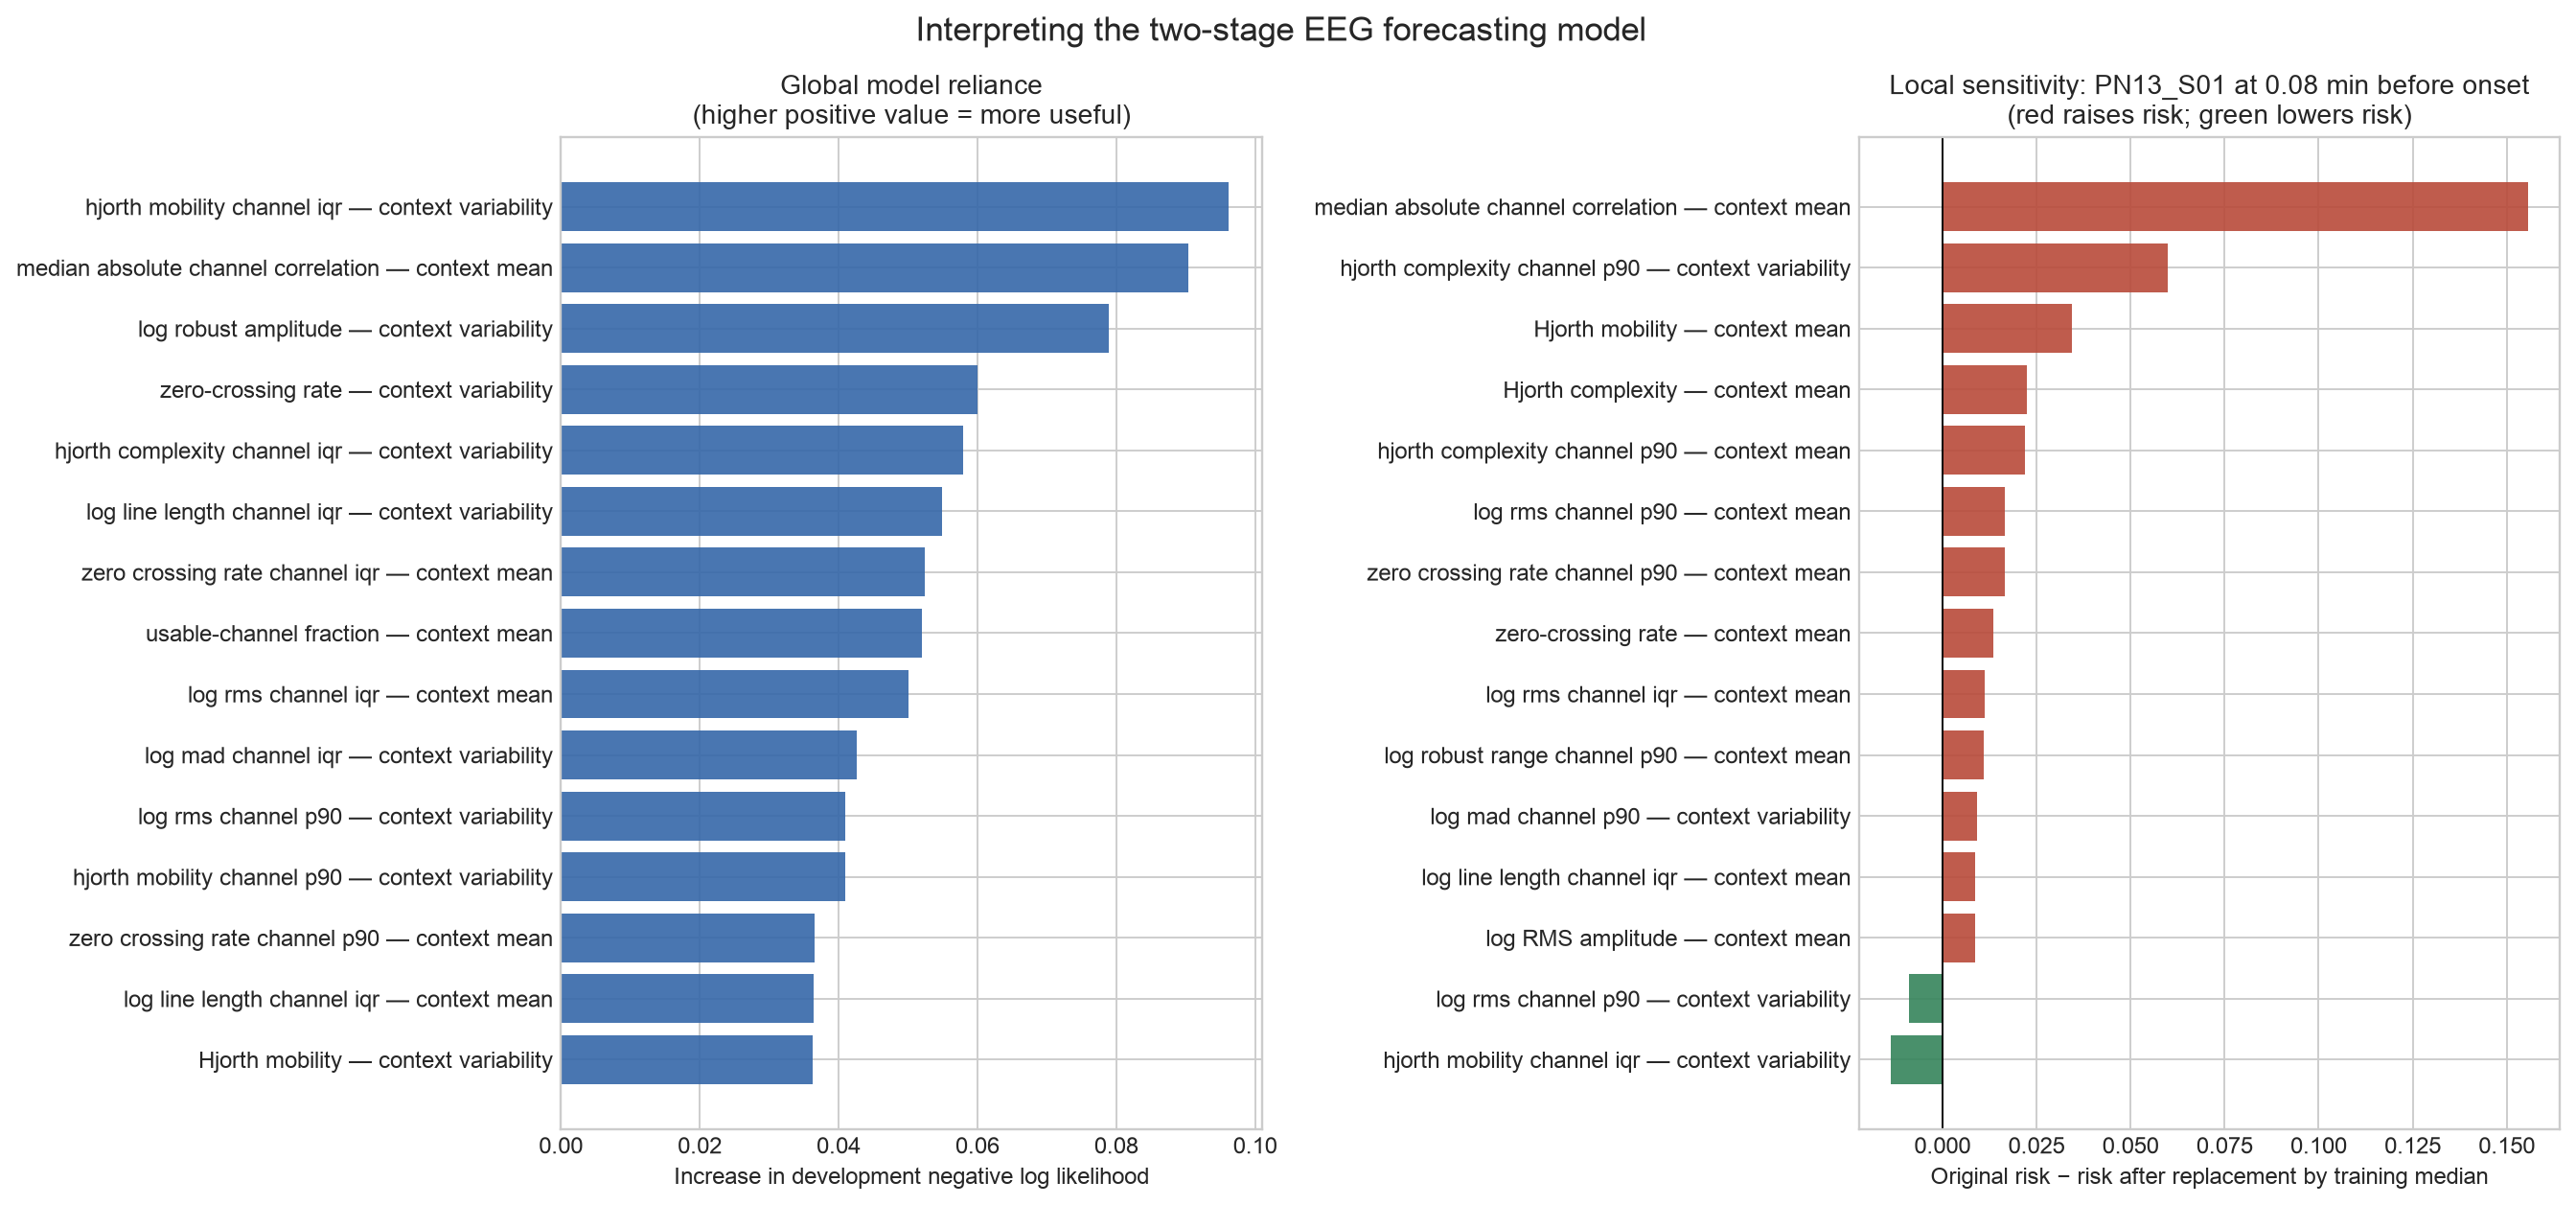

### Automated regression tests

Passed **15/15** tests.

### Completion checklist

requirement,passed
exact seizure quotas,True
seizures disjoint across splits,True
two-minute causal EEG context,True
same enabled EEG channels in development and test,True
grouped out-of-fold tuning covers development,True
"configurable m, r, and i",True
r/i probabilities at every reading,True
first reading at -m and last at onset,True
"peak matrix entries are (bin, probability)",True
all probability mass sums to one,True


Notebook complete: 47 disjoint seizures, 61 readings per seizure, 60 future bins per reading, 172,020 saved bin probabilities.


In [ ]:
from IPython.display import Image

display(Markdown("### Parameters"))
display(parameter_table.style.hide(axis="index"))

display(Markdown("### Exact split sizes"))
display(split_summary.style.hide(axis="index"))

display(Markdown("### Final held-out alarm dashboard"))
display(Markdown(
    "Sensitivity and false alarms use the persistent alarm state; AUROC uses continuous risk. "
    "The confusion matrix is landmark-level, so it complements rather than replaces episode-level sensitivity."
))
display(Image(filename=str(dashboard_path)))
display(dashboard_table.style.format({"value": "{:.4f}"}).hide(axis="index"))
display(tradeoff_table.style.format({"held_out_value": "{:.4f}"}).hide(axis="index"))

display(Markdown("### Held-out test metrics"))
display(test_metrics.style.format({"value": "{:.4f}"}).hide(axis="index"))

display(Markdown(
    "### Test peak-bin matrix\n"
    "Every entry is `(highest-probability future bin, probability)`. "
    "Rows run from `m` minutes before onset through the onset boundary."
))
display(test_peak_matrix.style.hide(axis="index"))

display(Markdown("### Every test reading probability graph"))
display(Image(filename=str(heatmap_path)))

display(Markdown("### Model interpretation"))
display(global_importance.head(15).style.format({
    "importance_nll_increase": "{:.6f}",
    "importance_std": "{:.6f}",
}).hide(axis="index"))
display(local_explanation.head(15).style.format({
    "risk_change_when_observed": "{:+.6f}",
    "counterfactual_event_risk": "{:.4f}",
}).hide(axis="index"))
display(Image(filename=str(interpretability_path)))

display(Markdown("### Automated regression tests"))
display(Markdown(
    f"Passed **{regression_result.testsRun}/"
    f"{regression_result.testsRun}** tests."
))

display(Markdown("### Completion checklist"))
display(completion.style.hide(axis="index"))

print(
    f"Notebook complete: {len(seizure_allocation)} disjoint seizures, "
    f"{config.reading_count} readings per seizure, "
    f"{config.n_bins} future bins per reading, "
    f"{len(reading_probabilities):,} saved bin probabilities."
)
